# Wine quality analysis

A personal learning notebook exploring red-wine measurements through distributions, correlations, hypothesis tests and statistical models.

Use the Python 3.12 environment in `uv.lock`. Run the notebook from a fresh kernel, from top to bottom. The verification script checks execution, dataset integrity, separated classification splits and dashboard responses. Saved outputs are regenerated from the maintained environment.

The analysis is exploratory: feature choices followed inspection of this dataset, so even a separate test split is not an independent external validation. No production performance or causal effect is claimed.

In [1]:
%matplotlib inline
# For data manipulation
import pandas as pd
import numpy as np

# For visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# For statistical analysis
import statsmodels.api as sm
from scipy import stats
import pingouin as pg

# For machine learning and regressions
from sklearn.metrics import (
    auc, 
    roc_curve,
    classification_report, 
    confusion_matrix, 
    precision_recall_curve, 
    precision_score, 
    recall_score, 
    f1_score,
    mean_squared_error, 
    r2_score
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# Importing helper functions from utils.py
from wine_quality_utils import (
    plot_heatmap,
    create_qq_plot,
    create_distributions,
    create_distributions_with_qqplot,
    outliers_count,
    fit_and_evaluate_model, 
    preprocess_data, 
    plot_diagnostic_plots, 
    plot_cooks_distance, 
    extract_and_rank_model_metrics,
    generate_partial_residual_plots
)

In [2]:
import warnings
warnings.simplefilter("default")
np.random.seed(42)

plot_style = {
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12
}

plt.rcParams.update(plot_style)
sns.set_context(rc=plot_style)
sns.despine(left=True, bottom=True)

<Figure size 1000x600 with 0 Axes>

In [3]:
wine_data = pd.read_csv("winequality-red.csv")

## Understanding the Data
i. Previewing the data 

ii. Looking at the dataframe structure, missing values, data types,duplicated rows 

iii. Summary statistics

----

**Preview**

In [4]:
display(wine_data.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
display(wine_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

- No missing values
- All features are numerical 

In [6]:
print(f'The number of duplicated rows in the dataset are: {wine_data.duplicated().sum()}')

The number of duplicated rows in the dataset are: 240


Exact duplicate rows are removed for this analysis to avoid placing identical records in different splits. The source has no record identifier, so this is an analytical choice, not proof that repeated measurements are errors. The dashboard retains all original records.

In [7]:
wine_data = wine_data.drop_duplicates()

### Measurements

The [UCI Wine Quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) records fixed and volatile acidity, citric acid, residual sugar, chlorides, free and total sulfur dioxide, density, pH, sulphates and alcohol. The target is a sensory quality rating on a 0–10 scale. Consult the source for measurement definitions; this notebook does not make chemical or medical recommendations.

In [8]:
summary_statistics = wine_data.describe()

In [9]:
display(summary_statistics)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Univariate Analysis
-  without preprocessing Data

Distribution of quality of wines


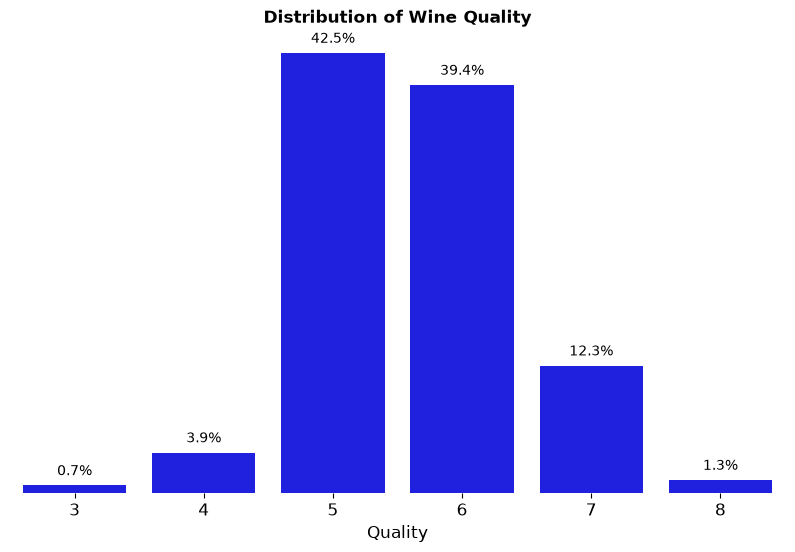

In [10]:
quality_counts = wine_data['quality'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
barplot = sns.barplot(x=quality_counts.index, y=quality_counts.values, color="blue", ax=ax)

ax.bar_label(ax.containers[0], fmt='%.1f%%', label_type='edge', padding=5, color='black', fontsize=10)

ax.set_ylabel('')
ax.set_yticks([])
ax.set_xlabel('Quality')
ax.set_title('Distribution of Wine Quality', fontweight='bold')
sns.despine(left=True, bottom=True)

plt.show()

- We can define wine quality greater than 6 as high quality wine i.e quality 7 and 8

In [11]:
print('Our sample data for high quality wine is :' ,wine_data[wine_data['quality'] > 6].shape[0])

Our sample data for high quality wine is : 184


- The sample size would be important for statistical analysis later

### Understand the basic properties of the dataset,
  - distribution of data for each feature
  - presence of outliers, and general data quality.


**Visualizing the Distribution of data for each features**

[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


...

[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


[environment]\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


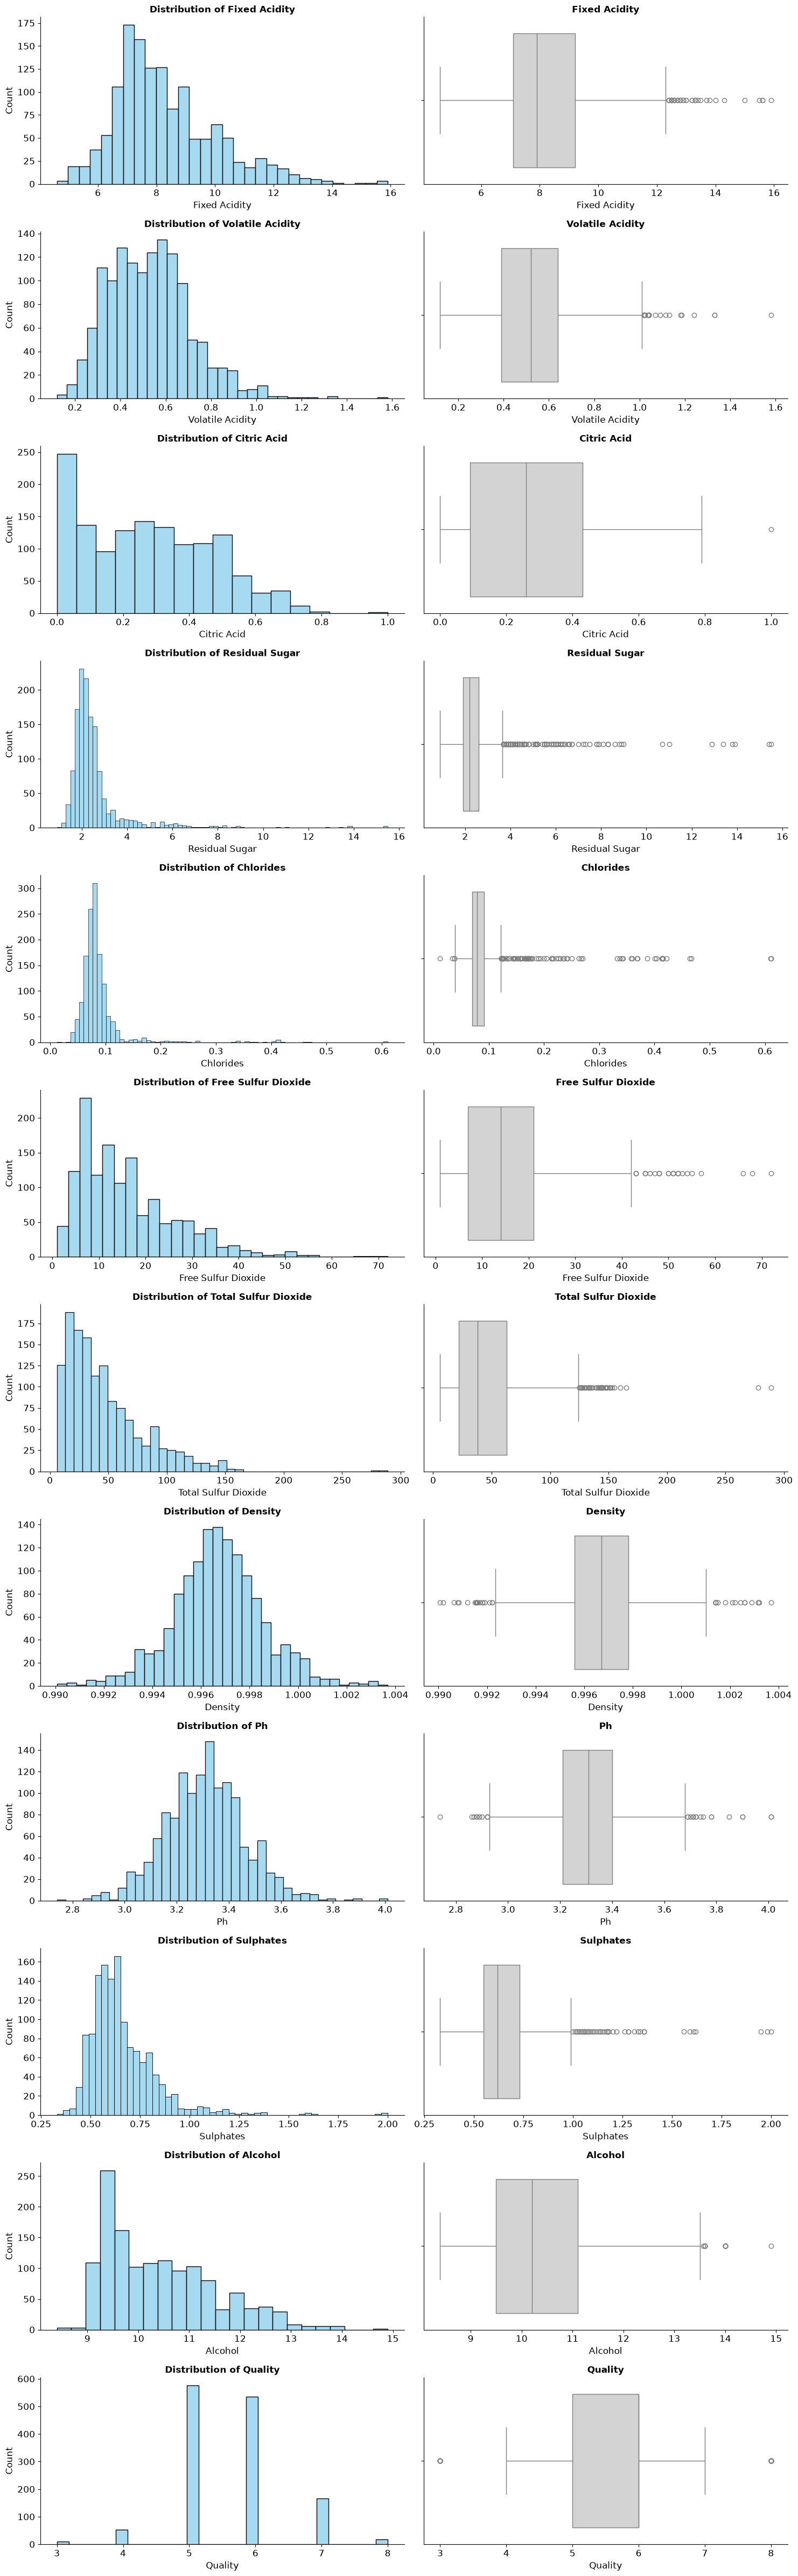

In [12]:
create_distributions(wine_data)


The histograms show asymmetric distributions in several measurements. Density and pH look more symmetric, but visual appearance does not prove normality. Quality is a discrete ordinal rating, concentrated around 5 and 6. Boxplots flag unusual values for inspection rather than automatic removal.

#### Quantifying distribution properties

In [13]:
outliers_count(wine_data).sort_values(by = ["Skewness"], ascending  = False)

,Outliers,Extreme Outliers,Skewness
chlorides,87,60,5.502487
residual sugar,126,70,4.548153
sulphates,55,15,2.406505
total sulfur dioxide,45,2,1.540368
free sulfur dioxide,26,3,1.226579
fixed acidity,41,4,0.941041
alcohol,12,0,0.859841
volatile acidity,19,1,0.729279
citric acid,1,0,0.312726
pH,28,2,0.232032


Highly skewed features
- Residual Sugar
- Chlorides
- Sulphates
- Free Sulfur Dioxide
- Total Sulfur Dioxide

The IQR and skewness table describes this sample. Unusual values are not automatically errors, and transformations need to be assessed in the context of the analysis.

**Note!**

Using the IQR method, wine ratings of 3 and 8 are outliers, but given the context, it's important not to discard them. Most ratings fall around 5 or 6, yet these outliers hold valuable information.


In [14]:
wine_data['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

**Checking for normality of features** - for subsequent correlation analysis 

Pearson correlation measures linear association without requiring normal marginal distributions. Its usual parametric p-value relies on distributional assumptions; Spearman correlation provides a rank-based comparison.

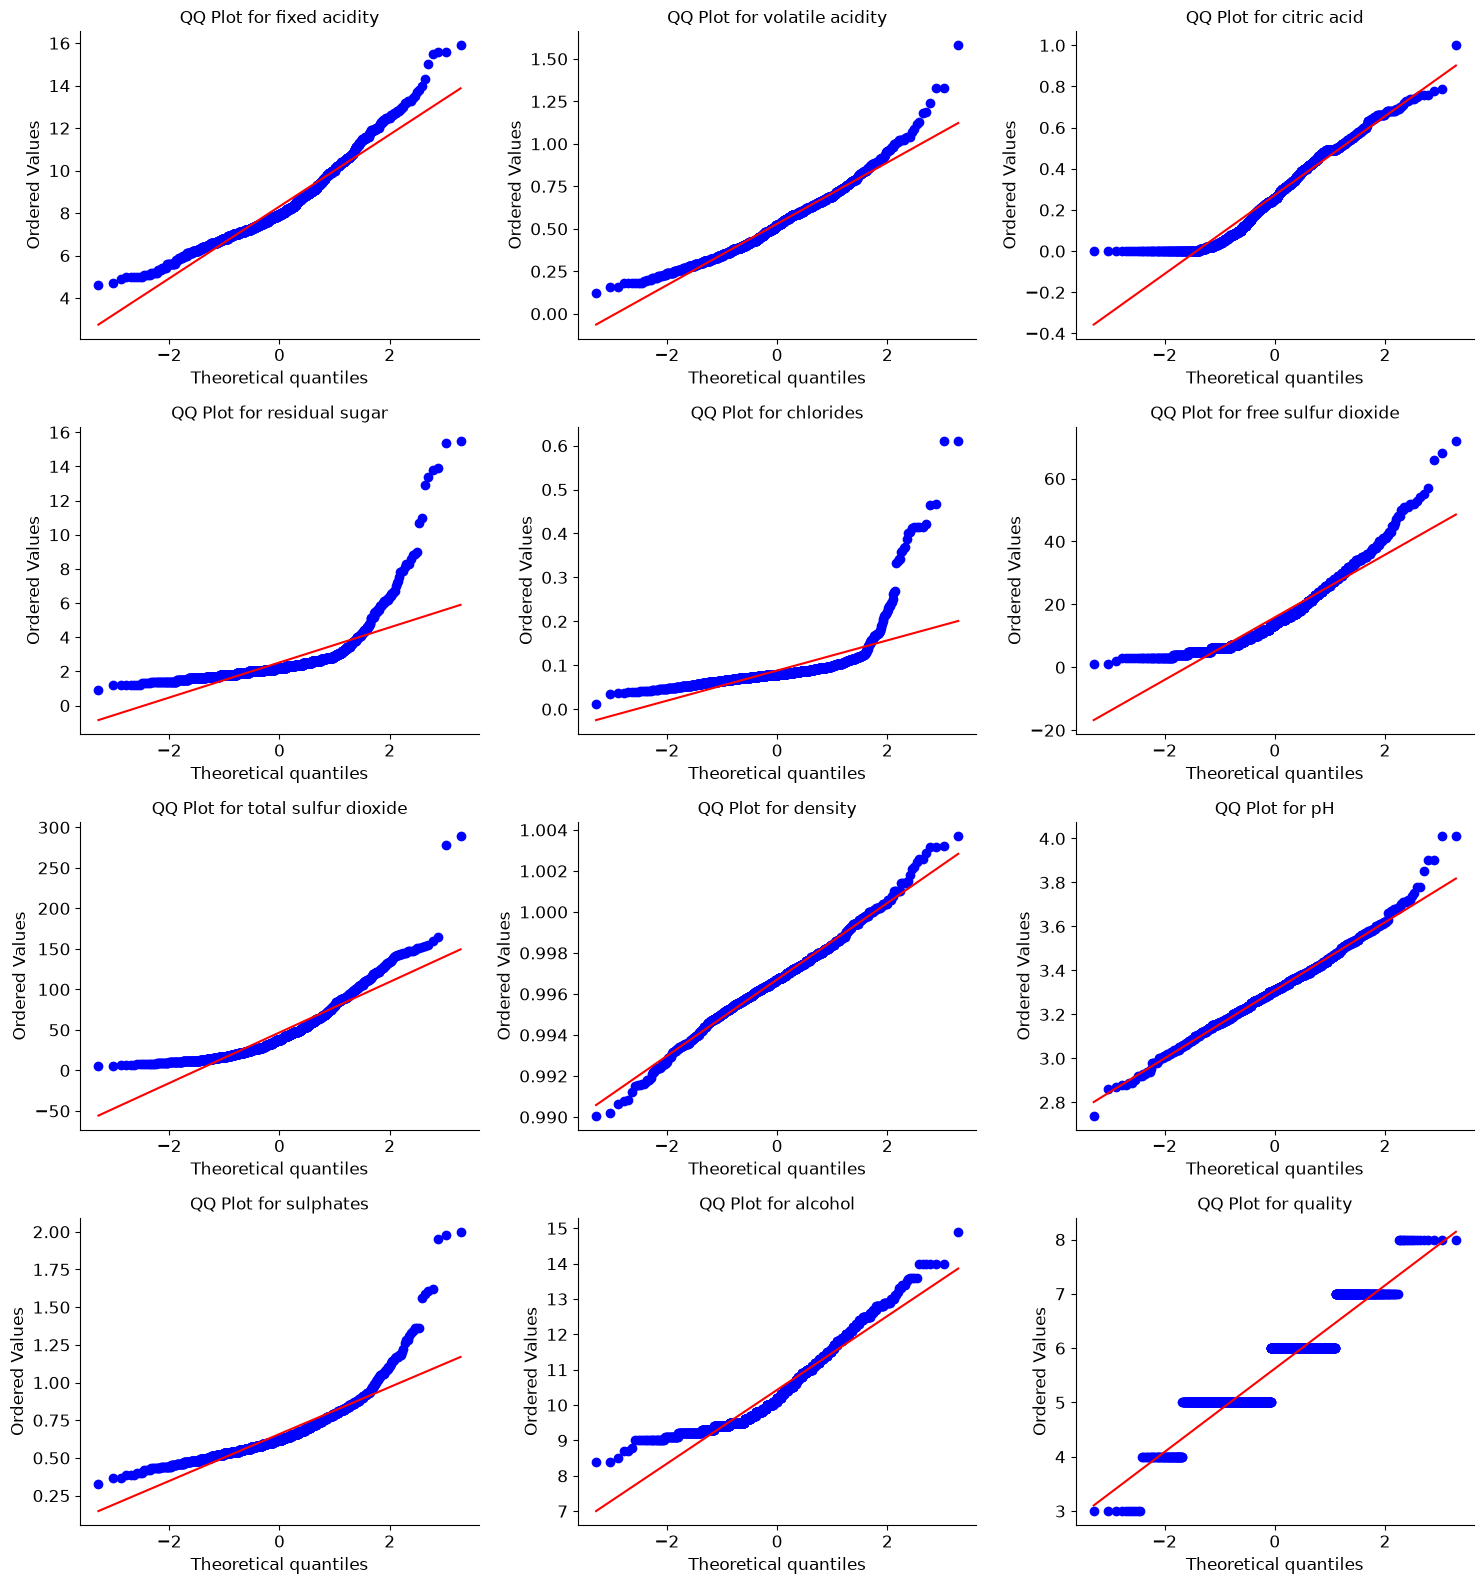

In [15]:
num_cols = wine_data.select_dtypes(include=['float64', 'int64']).columns
n_cols = 3
n_rows = (len(num_cols) + 2) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    create_qq_plot(wine_data, col, axes[i])

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

fig.tight_layout()
sns.despine()
plt.show()

The Q-Q plots show departures from normality, particularly in the upper tails of several features. These plots inform interpretation; they do not establish whether a regression model is valid. Regression diagnostics concern the conditional errors, not a requirement that every input feature be normally distributed.

Looking more closely at features with very high skewness:

In [16]:
high_skewed_features = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']

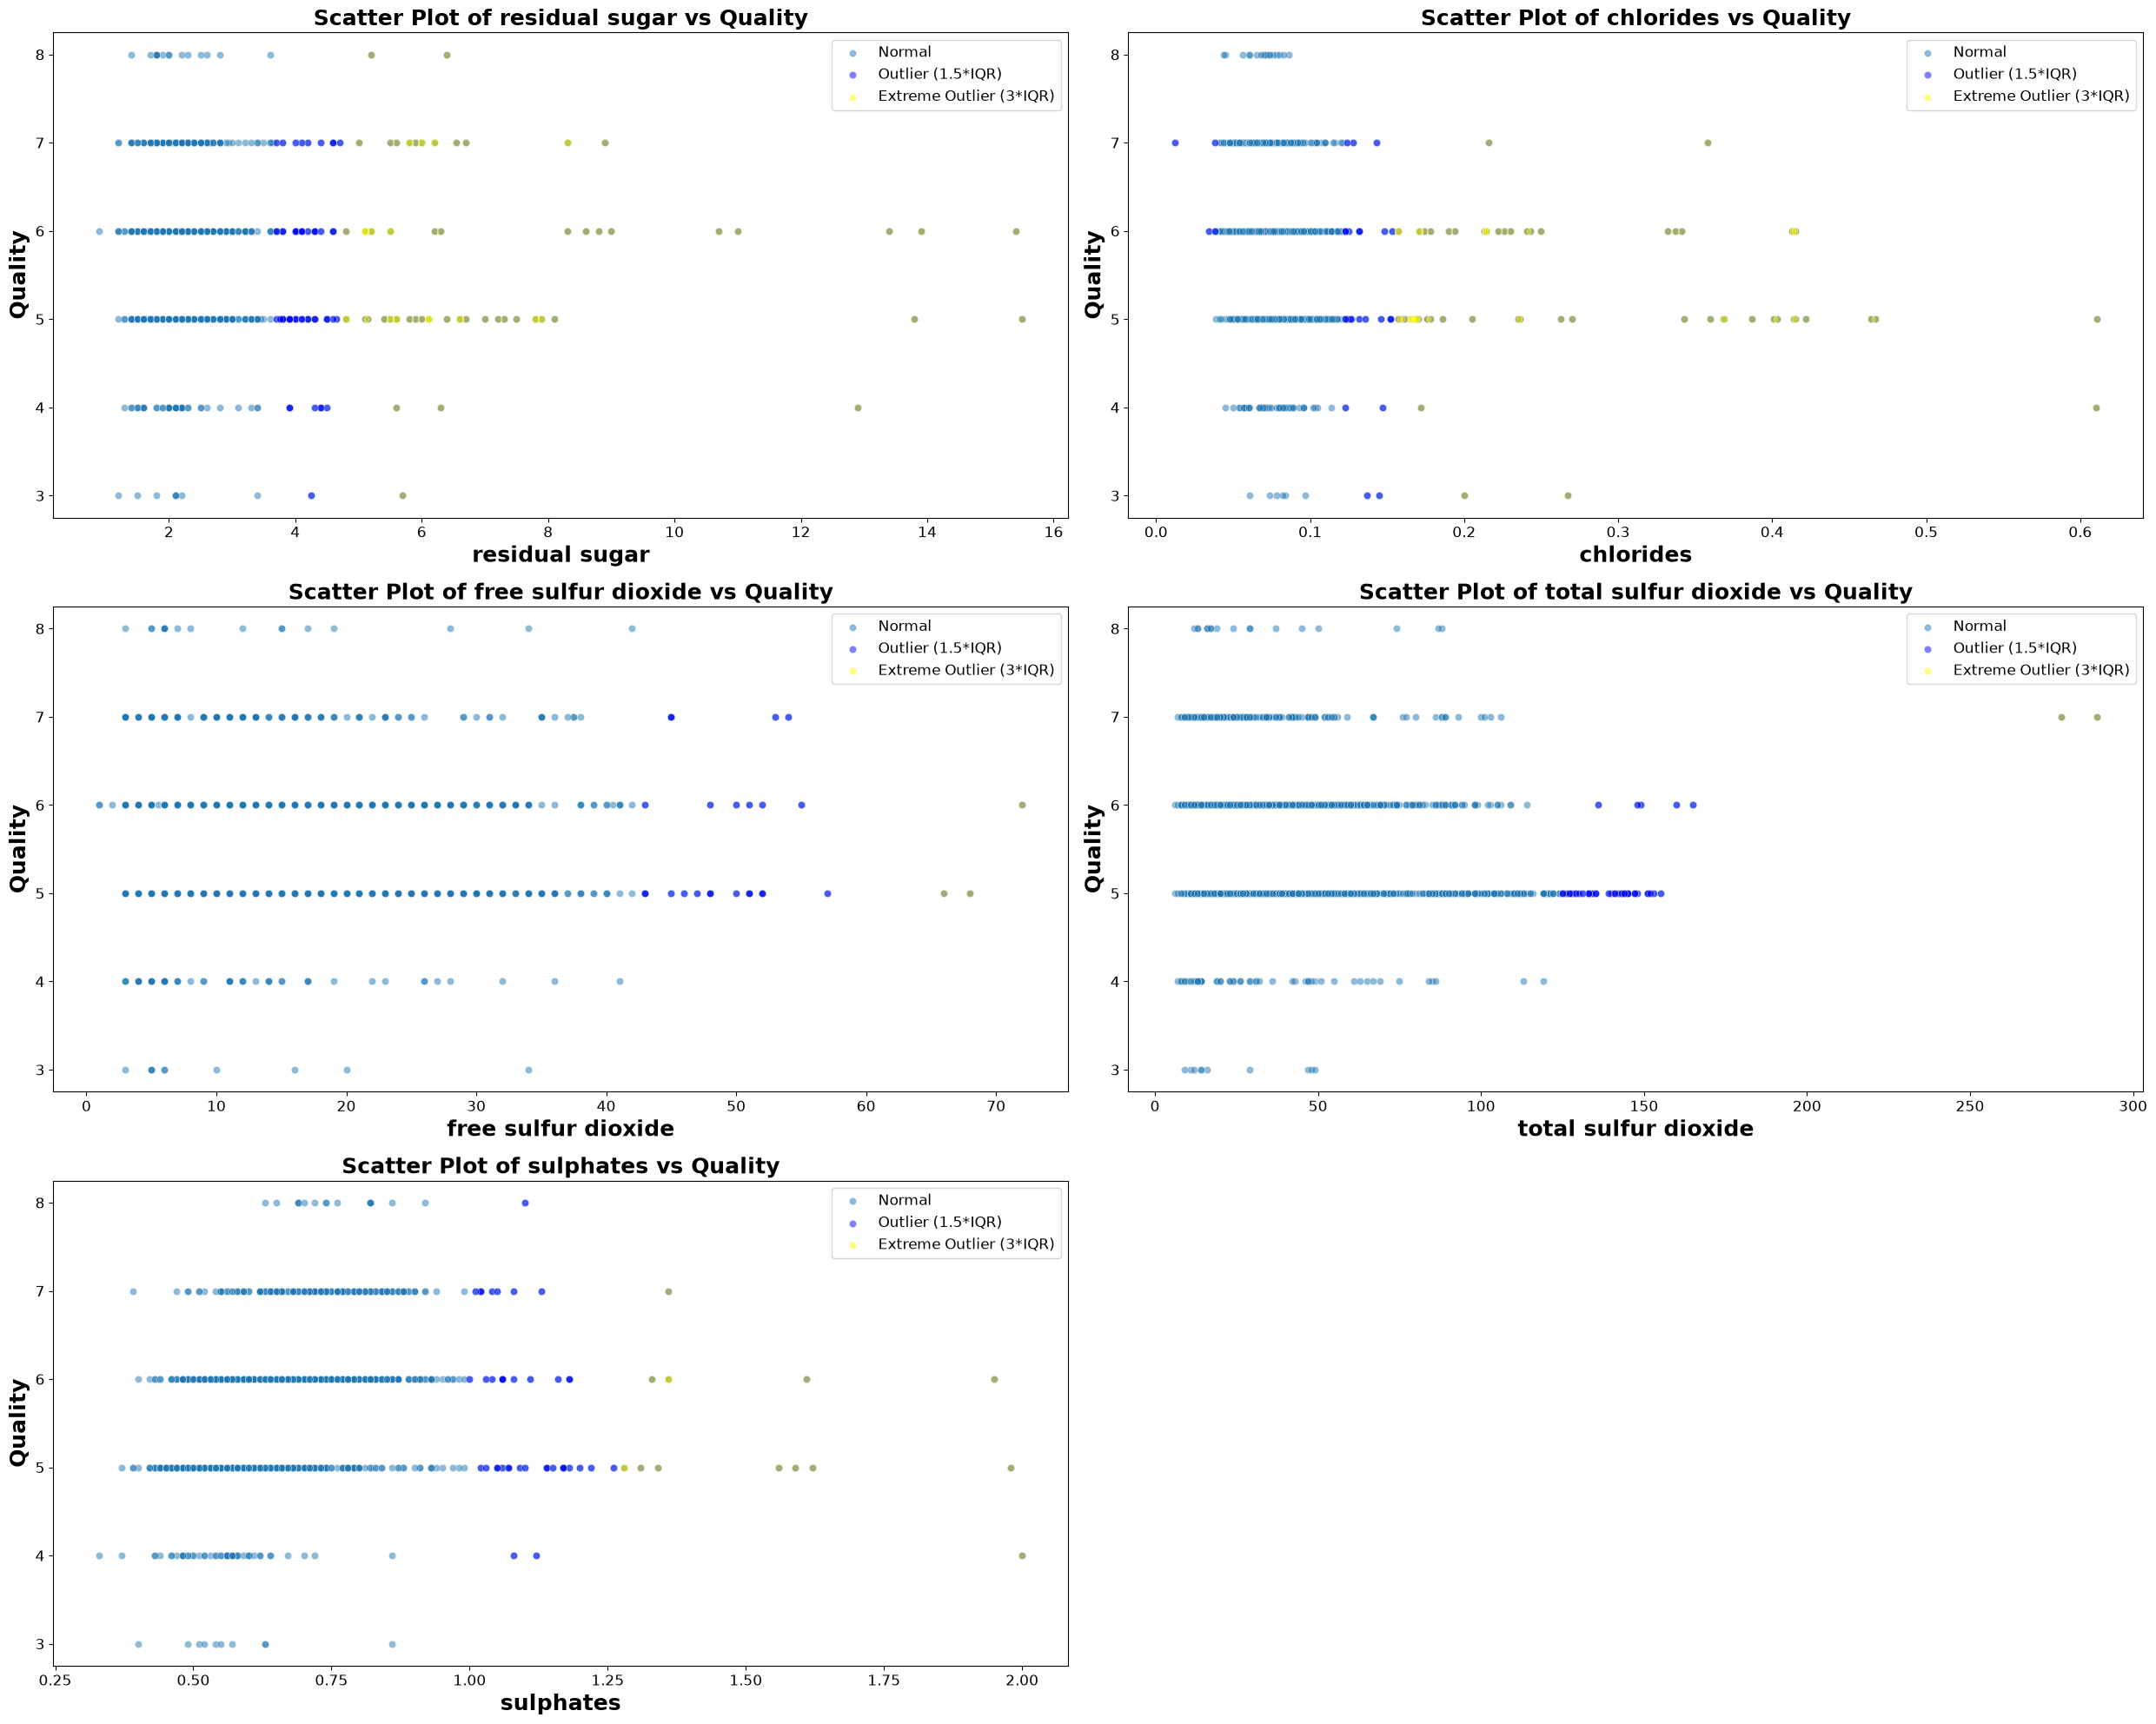

In [17]:
plt.figure(figsize=(25, 20))

for i, feature in enumerate(high_skewed_features, 1):
    ax = plt.subplot(3, 2, i)
    
    Q1 = wine_data[feature].quantile(0.25)
    Q3 = wine_data[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers_mask = (wine_data[feature] < (Q1 - 1.5 * IQR)) | (wine_data[feature] > (Q3 + 1.5 * IQR))
    extreme_outliers_mask = (wine_data[feature] < (Q1 - 3 * IQR)) | (wine_data[feature] > (Q3 + 3 * IQR))
    
    sns.scatterplot(x=wine_data[feature], y=wine_data['quality'], alpha=0.5, label='Normal', ax=ax)
    
    sns.scatterplot(x=wine_data[feature][outliers_mask], y=wine_data['quality'][outliers_mask], color='blue', alpha=0.5, label='Outlier (1.5*IQR)', ax=ax)
    
    sns.scatterplot(x=wine_data[feature][extreme_outliers_mask], y=wine_data['quality'][extreme_outliers_mask], color='yellow', alpha=0.5, label='Extreme Outlier (3*IQR)', ax=ax)
    
    plt.title(f'Scatter Plot of {feature} vs Quality', fontweight='bold', fontsize = 18)
    plt.xlabel(f'{feature}', fontweight='bold', fontsize = 18)
    plt.ylabel('Quality', fontweight='bold', fontsize = 18)
    plt.legend()

plt.tight_layout()
plt.show()

Unusual measurements are retained because a scatter plot alone cannot establish whether they are errors. Their influence is examined in the later model diagnostics.

#  Lets process the Data: 

- Outliers impact the correlation of linear relationship and as well as regression line. 

- Address skewness by applying transformation to features with  extreme outliers and high skewness 

In [18]:
wine_df2 = wine_data.copy()
transformed_features = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']

for feature in transformed_features:
    wine_df2[feature] = np.sqrt(wine_df2[feature])

In [19]:
combined_outliers_df = pd.concat([
    outliers_count(wine_df2[transformed_features]).rename(columns=lambda x: f"{x}_transformed"),
    outliers_count(wine_data[transformed_features]).rename(columns=lambda x: f"{x}_original")
], axis=1)

display(combined_outliers_df)

,Outliers_transformed,Extreme Outliers_transformed,Skewness_transformed,Outliers_original,Extreme Outliers_original,Skewness_original
residual sugar,114,58,2.923234,126,70,4.548153
chlorides,90,49,3.667649,87,60,5.502487
free sulfur dioxide,4,0,0.476858,26,3,1.226579
total sulfur dioxide,3,0,0.641341,45,2,1.540368
sulphates,46,7,1.574817,55,15,2.406505


Compare original and transformed skewness in the table. Square-root transformations reduce some upper-tail asymmetry but do not guarantee normally distributed features.

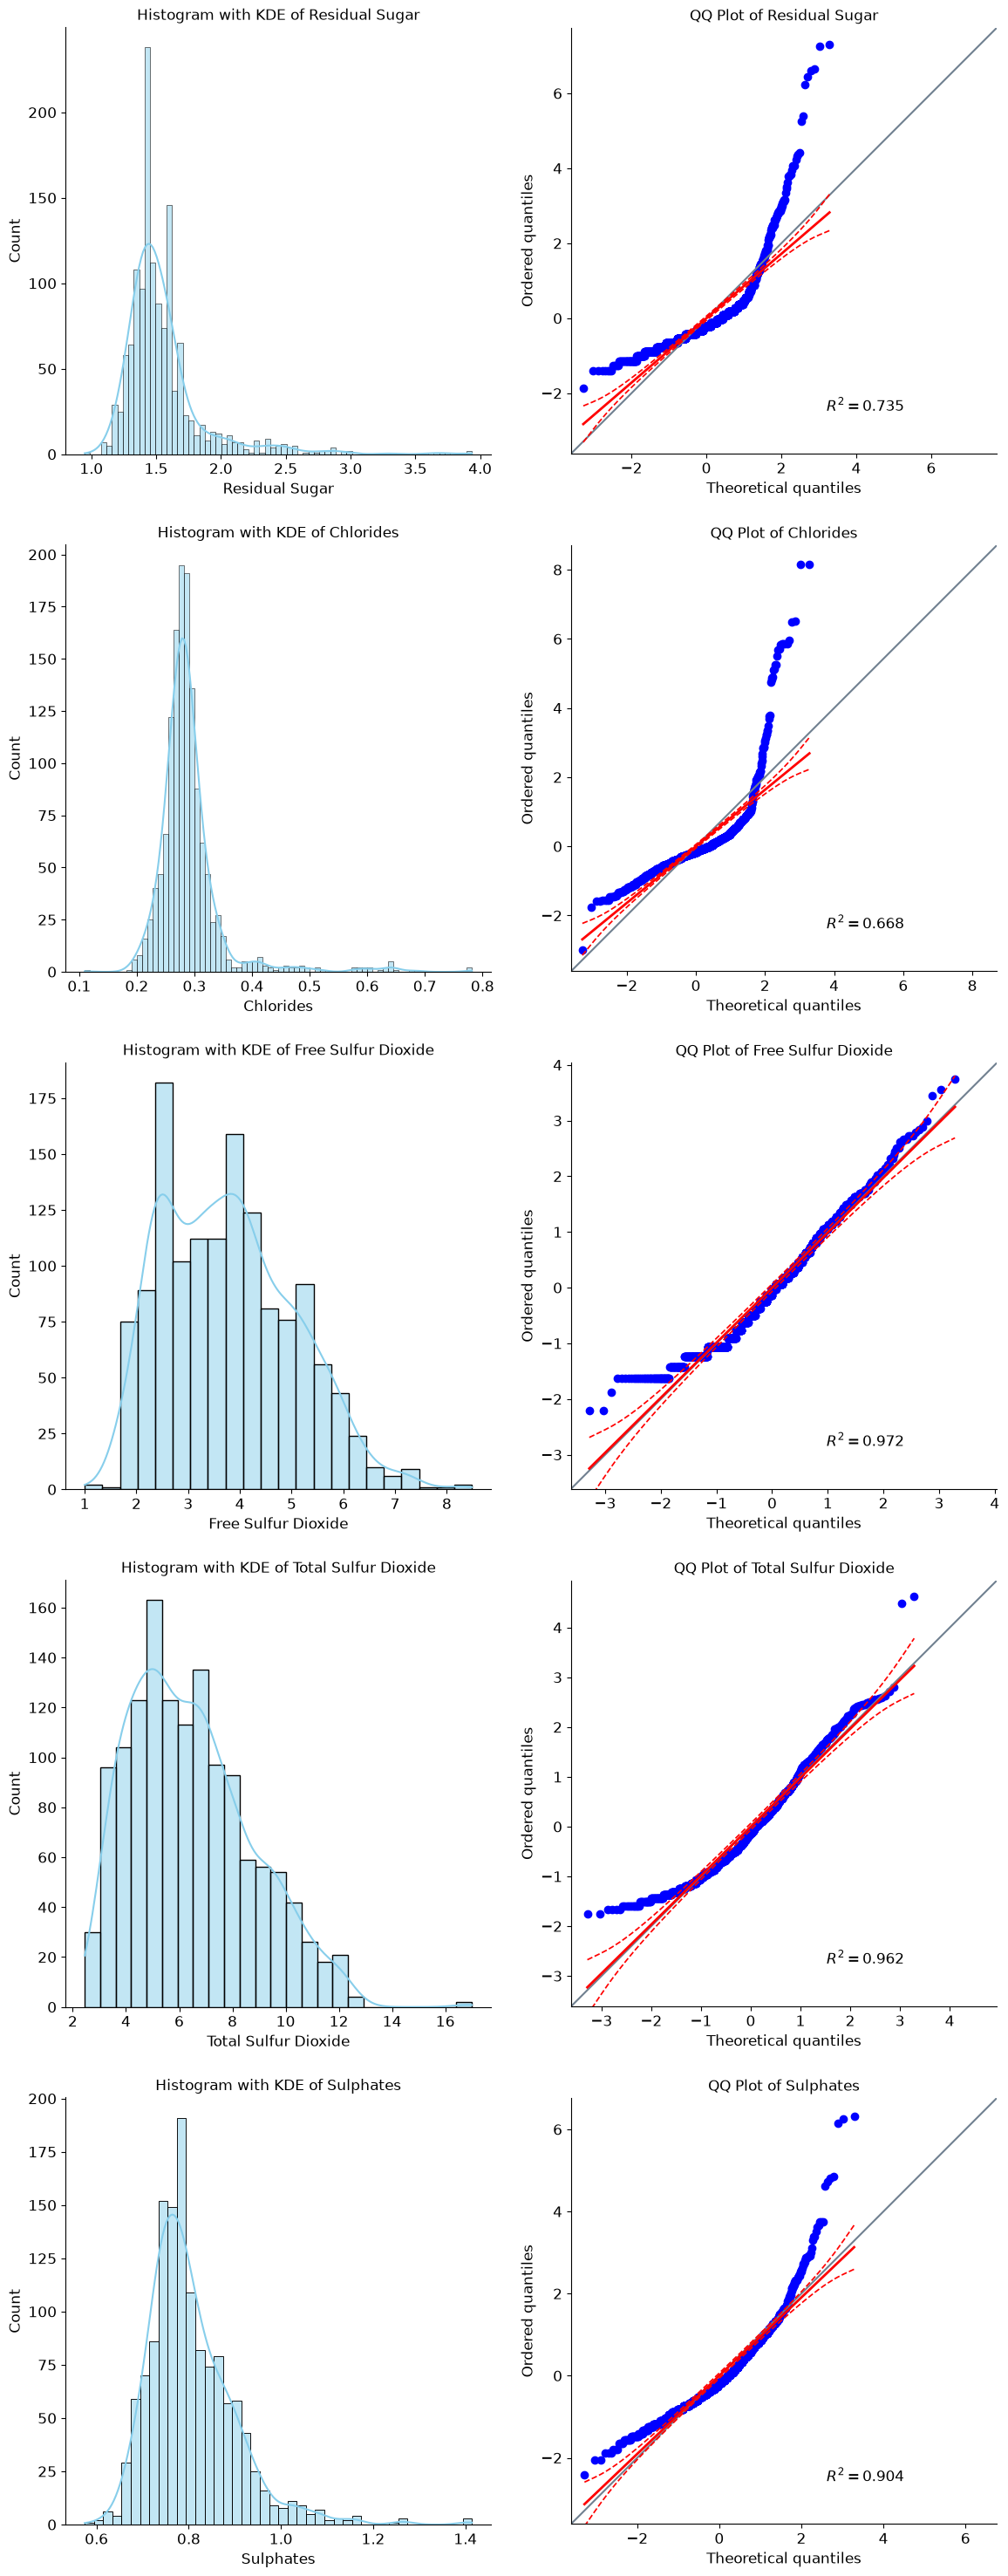

In [20]:
create_distributions_with_qqplot(wine_df2[transformed_features])

The transformed distributions still have tails and unusual observations.

These Q-Q plots concern feature distributions. Regression assumptions concern the errors conditional on predictors; nonnormal input features alone do not invalidate regression.

---

### Looking at the correlation between features and in particular to wine quality feature

# Bivariate Analysis

In [21]:
features = wine_df2.drop(['quality'], axis = 1)
quality = wine_df2['quality']

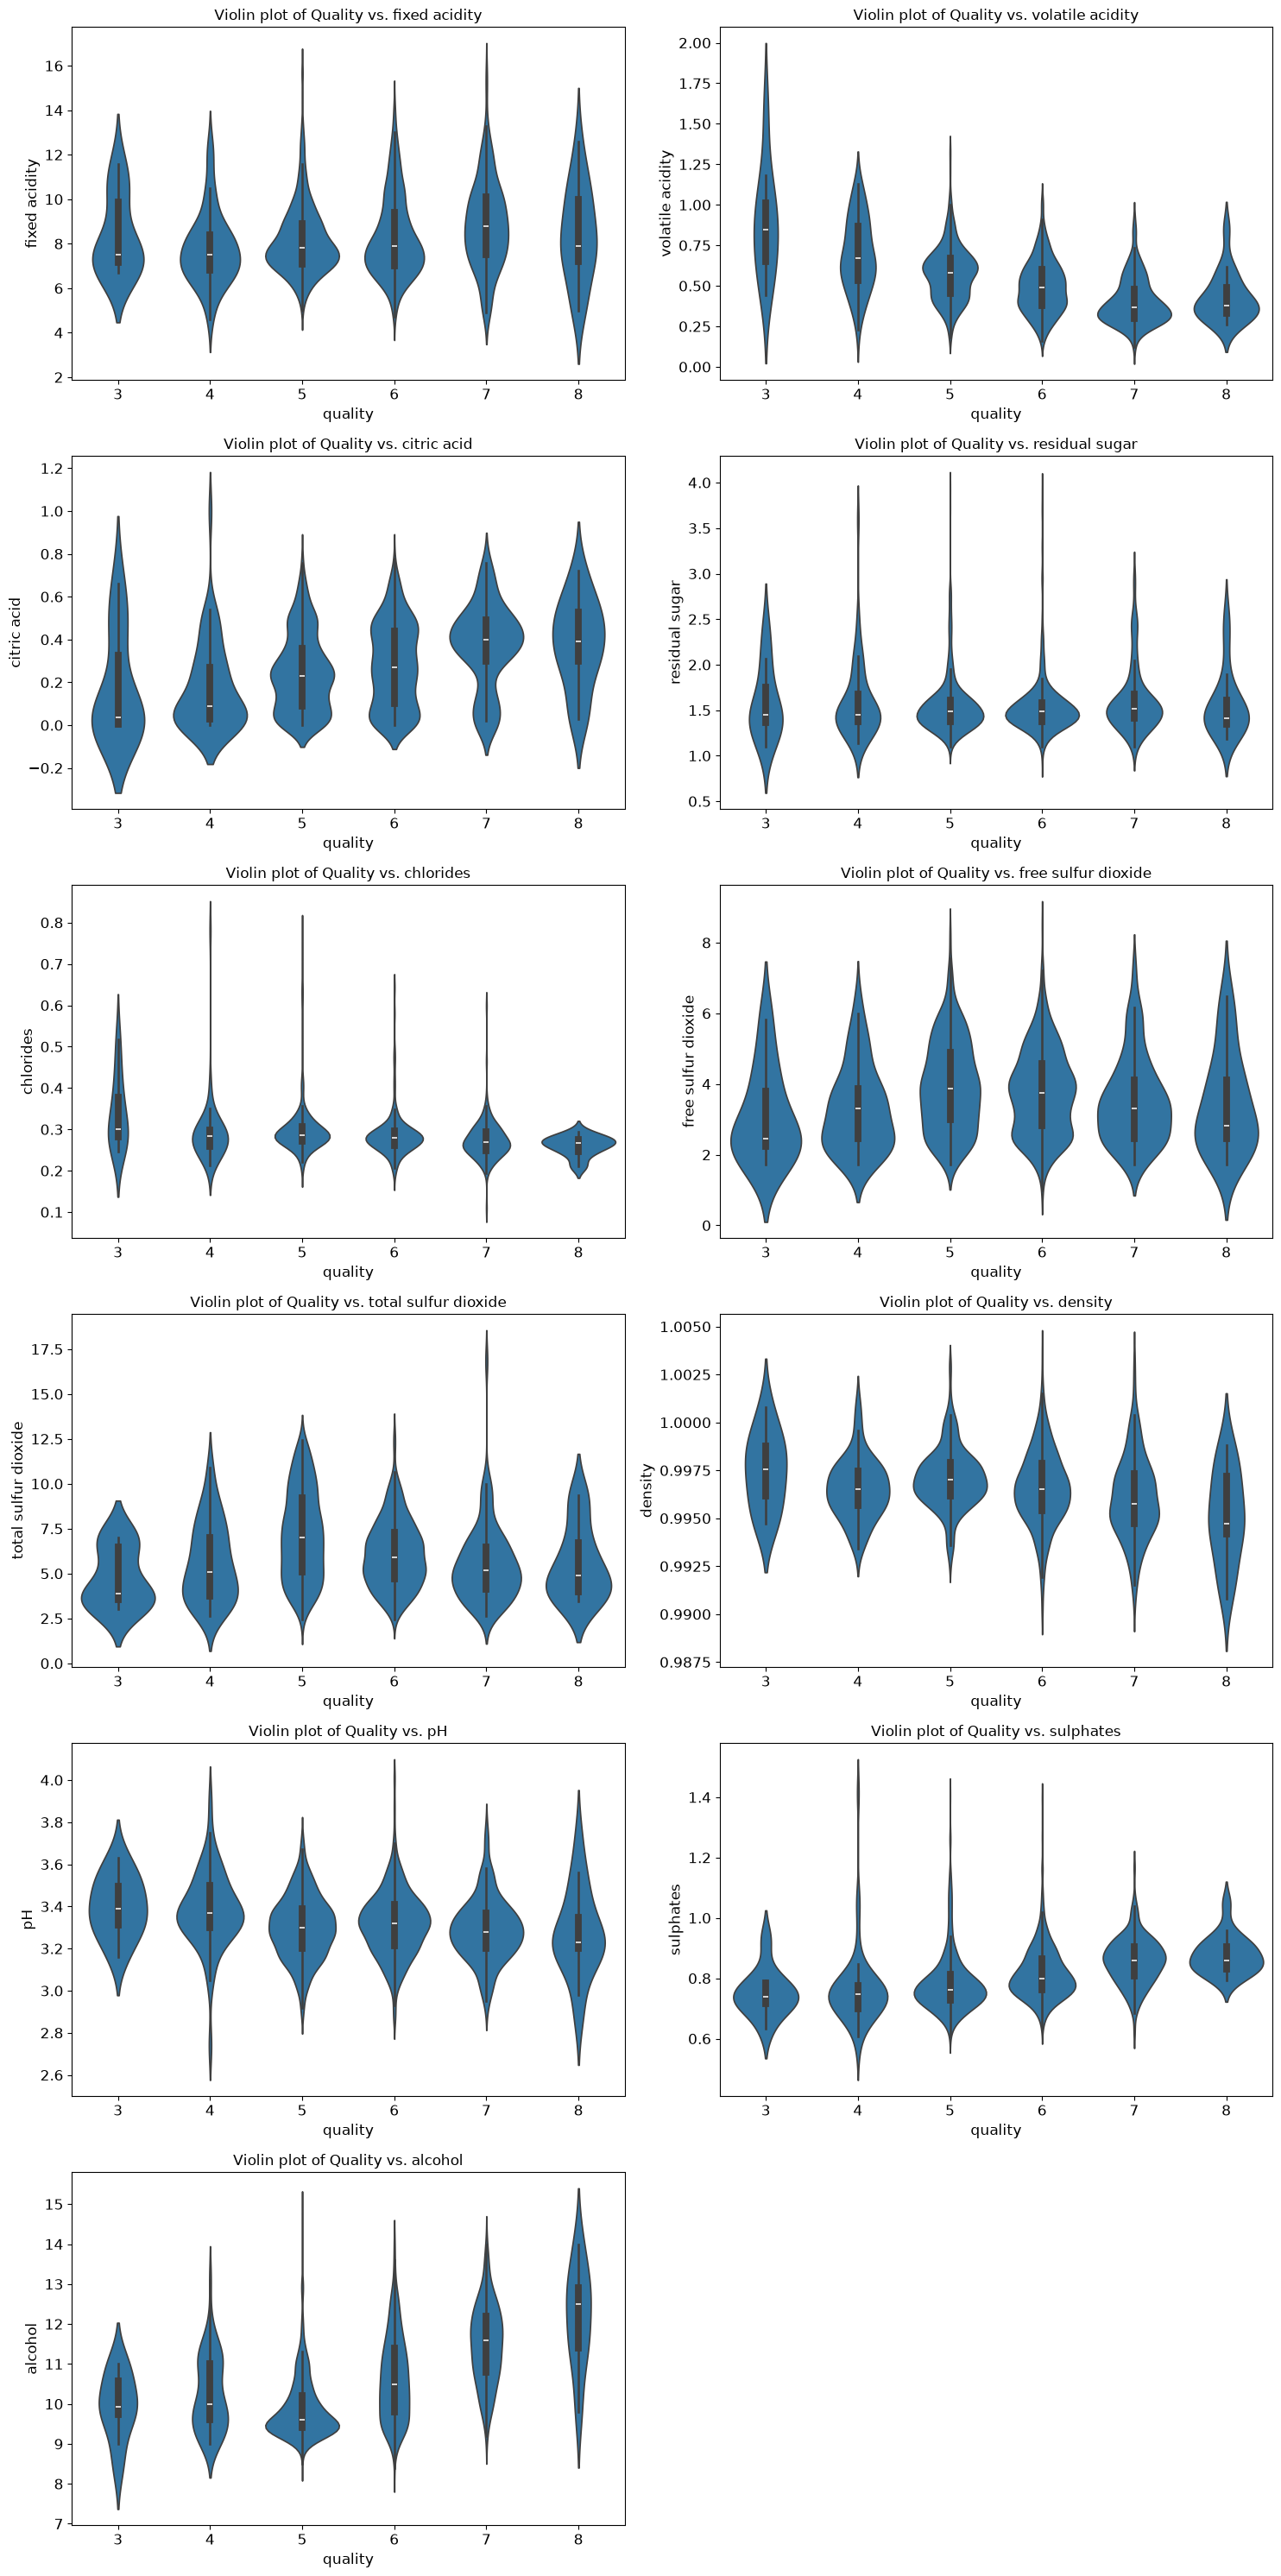

In [22]:
num_features = len(features.columns) 
num_rows = num_features // 2 if num_features % 2 == 0 else (num_features // 2) + 1

fig, axs = plt.subplots(num_rows, 2, figsize=(15, num_rows*5))  
axs = axs.ravel()

for i, feature in enumerate(features):
    sns.violinplot(x=quality, y=wine_df2[feature], ax=axs[i])
    axs[i].set_title(f'Violin plot of Quality vs. {feature}')

if num_features % 2 != 0:
    axs[-1].axis('off')

plt.tight_layout()
plt.show()

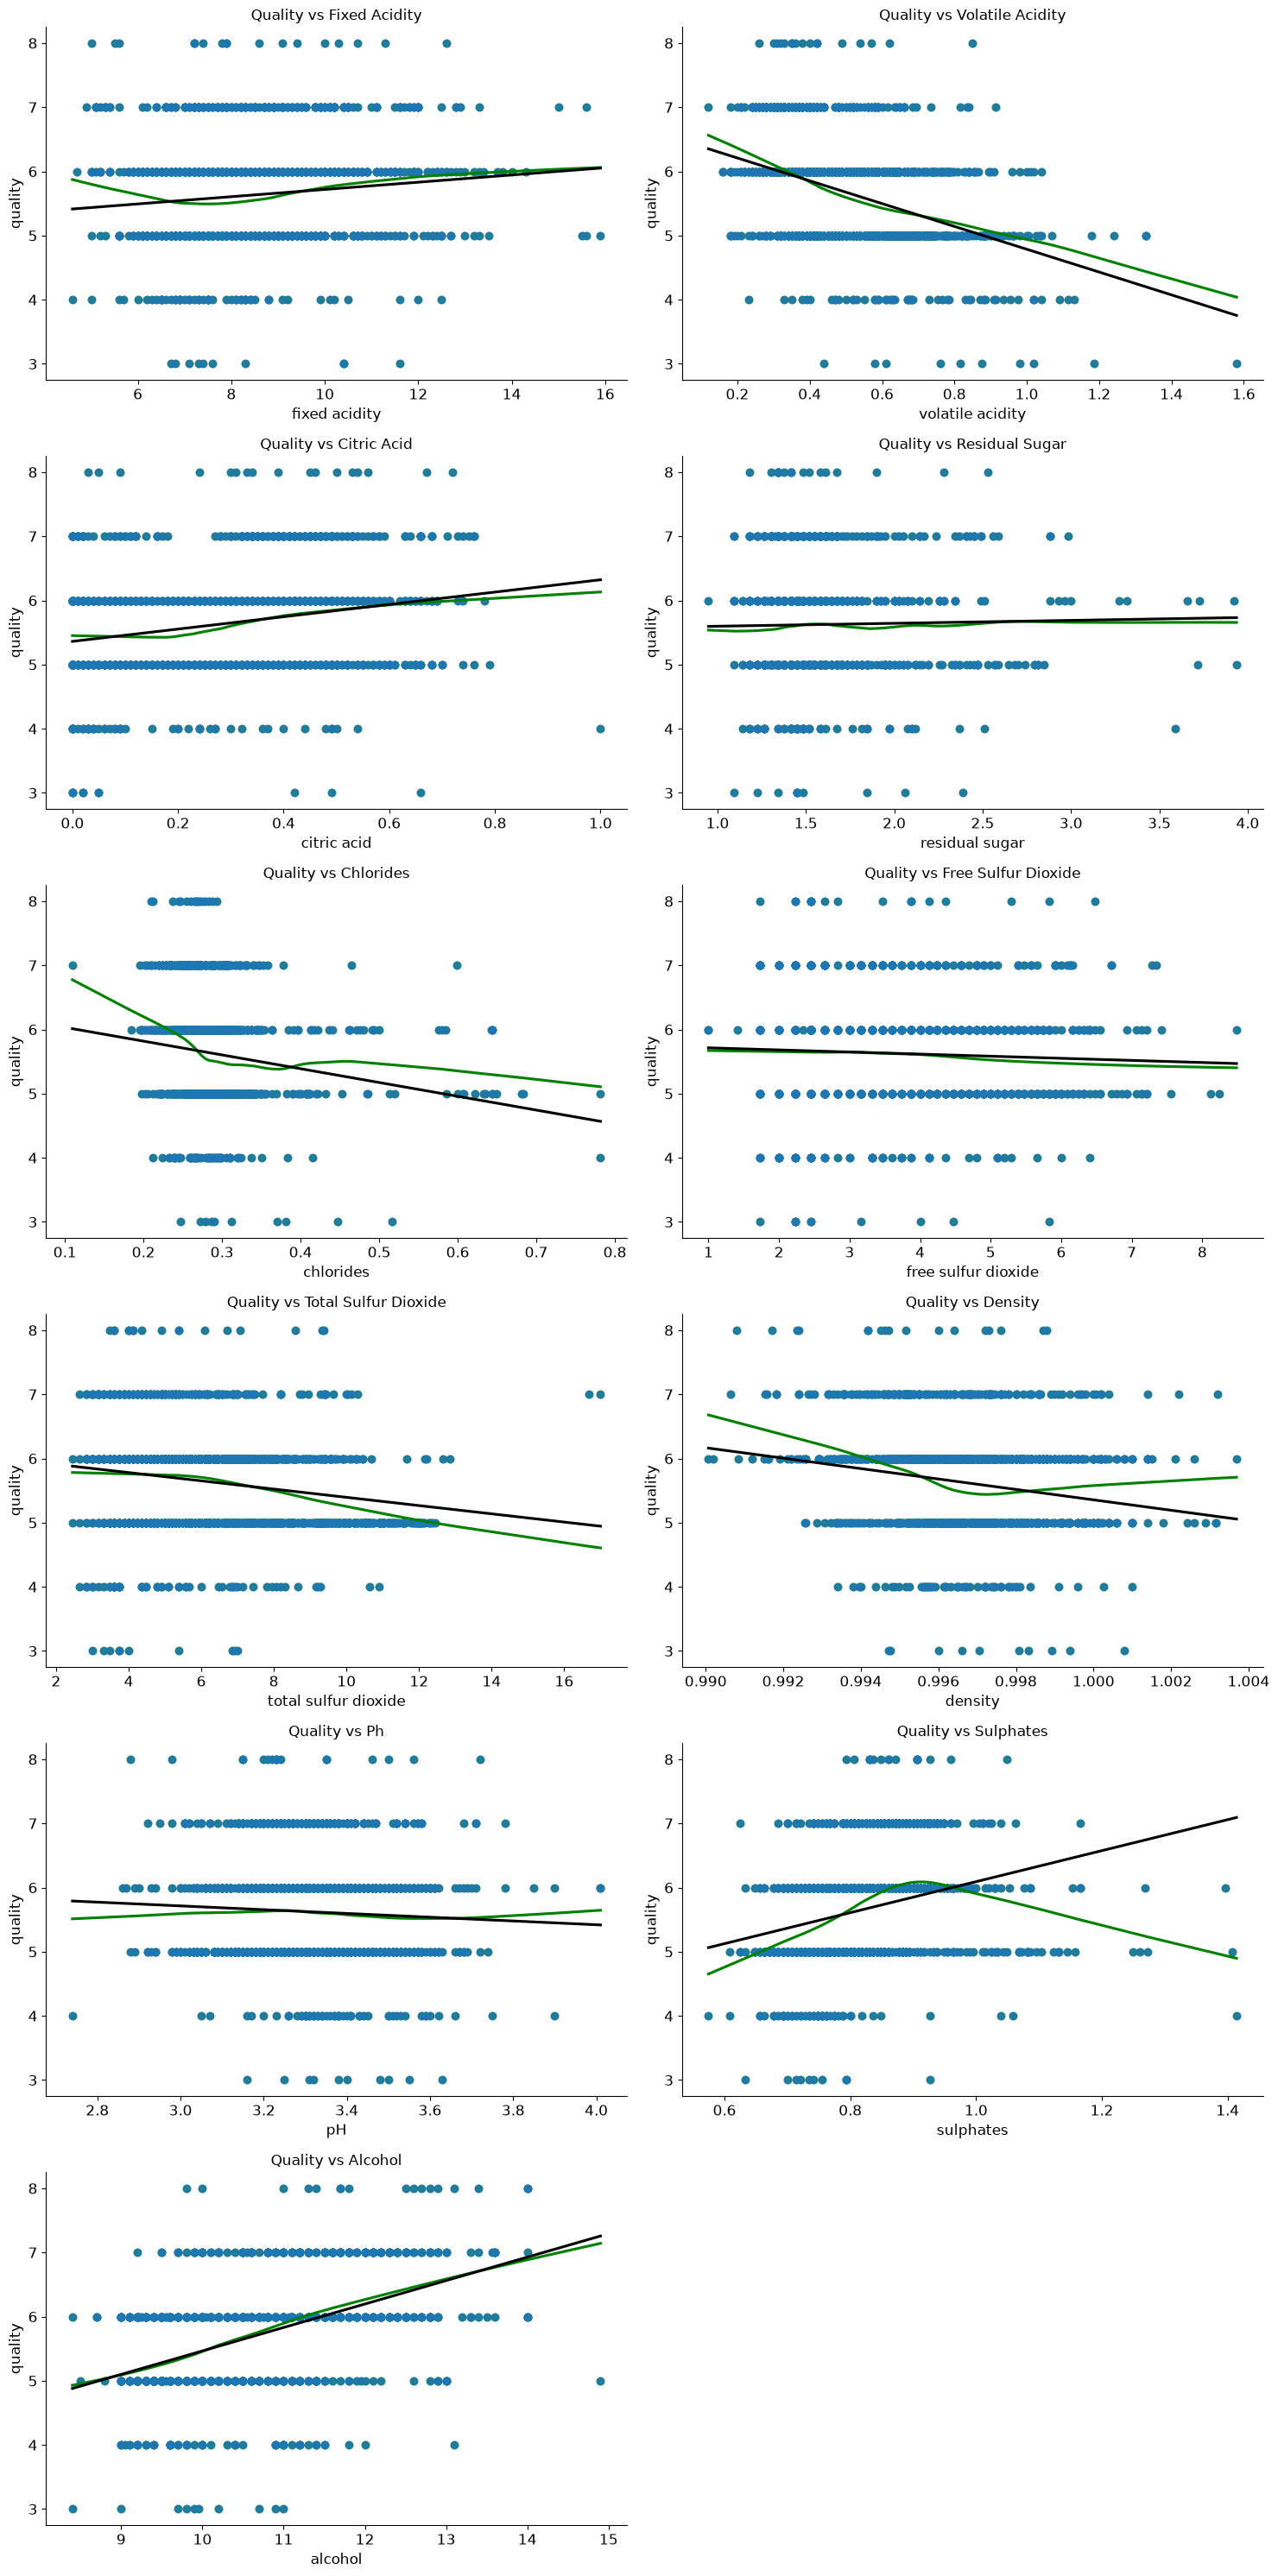

In [23]:
features = [col for col in wine_df2.columns if col != 'quality']

num_features = len(features)
num_cols = 2
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.regplot(x=feature, y='quality', data=wine_df2, lowess=True, ax=axes[i], color = "green")
    sns.regplot(x=feature, y='quality', data=wine_df2, line_kws= {"color" : "black"}, ci = None ,ax=axes[i])

    axes[i].set_title(f'Quality vs {feature.title()}')
       
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

sns.despine()
plt.tight_layout()
plt.show()

### Observed associations

The plots suggest positive associations of quality ratings with alcohol and sulphates and negative associations with volatile acidity and chlorides. These are sample patterns, not evidence that changing a measurement would change quality.

The later partial-residual plots explore the fitted relationship of each predictor with quality while accounting for the other predictors in that model.

# Correlation Analysis

#### Looking at Spearman correlation of feature w quality 

In [24]:
spearman_corr = wine_df2.corr(method='spearman')

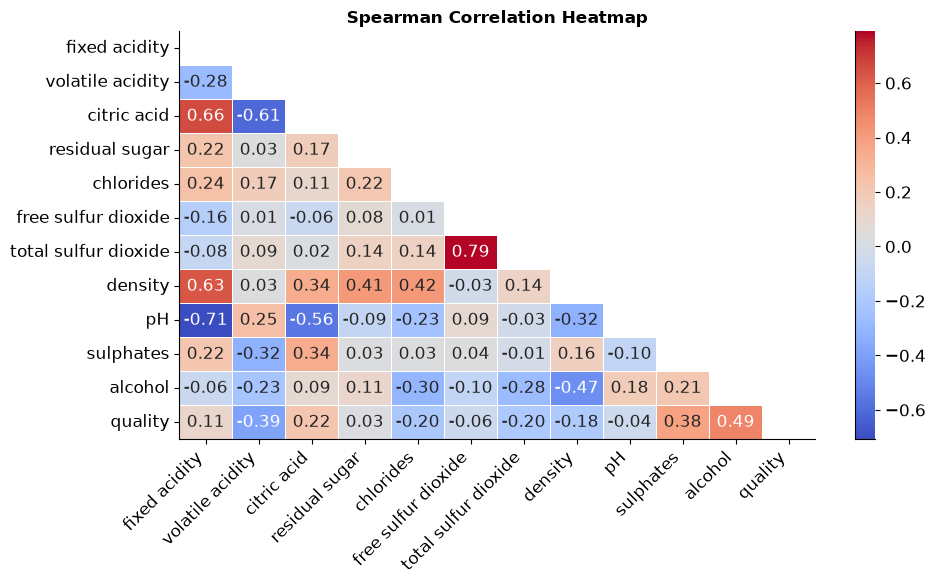

In [25]:
plot_heatmap(spearman_corr, 'Spearman Correlation Heatmap', 'spearman')
plt.show()

The heatmap reports sample Spearman correlations. Compare the displayed values directly; correlation does not establish a causal relationship. Correlated predictors can also make individual regression coefficients harder to interpret.

## Partial correlation

Rank associations with quality after adjusting for the other measured features. Adjustment does not establish causation.

In [26]:
target = 'quality'
features = wine_df2.columns.drop(target)
partial_rows = []
for feature in features:
    result = pg.partial_corr(data=wine_df2, x=feature, y=target,
                             covar=[c for c in features if c != feature], method='spearman')
    partial_rows.append({'Feature': feature, 'Partial correlation': result.at['spearman', 'r']})
partial_corr_matrix = pd.DataFrame(partial_rows).set_index('Feature')

[environment]\Lib\site-packages\seaborn\matrix.py:243: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  self.cmap.set_bad(bad)


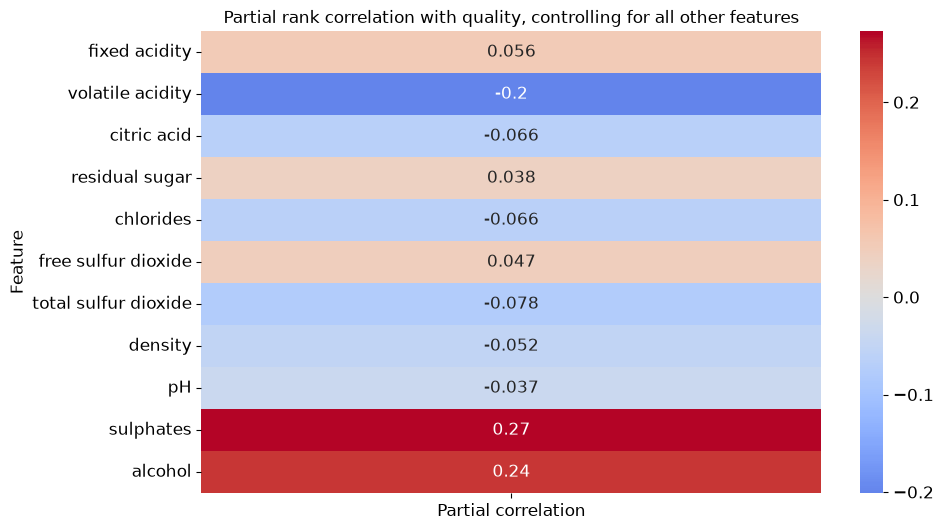

In [27]:
sns.heatmap(partial_corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Partial rank correlation with quality, controlling for all other features')
plt.show()

In [28]:
partial_corr_values = []
p_values = []

for feature in features:
    covariates = [col for col in features if col != feature]
    partial_corr = pg.partial_corr(data=wine_df2, x=feature, y=target, covar=covariates, method='spearman')
    
    if not partial_corr.empty:
        partial_corr_values.append(partial_corr.at['spearman', 'r'])
        p_values.append(partial_corr.at['spearman', 'p-val'])
    else:
        partial_corr_values.append(None)
        p_values.append(None)

partial_corr_df = pd.DataFrame({
    'Feature': features,
    'Partial Correlation with Quality': partial_corr_values,
    'p-value': p_values
})

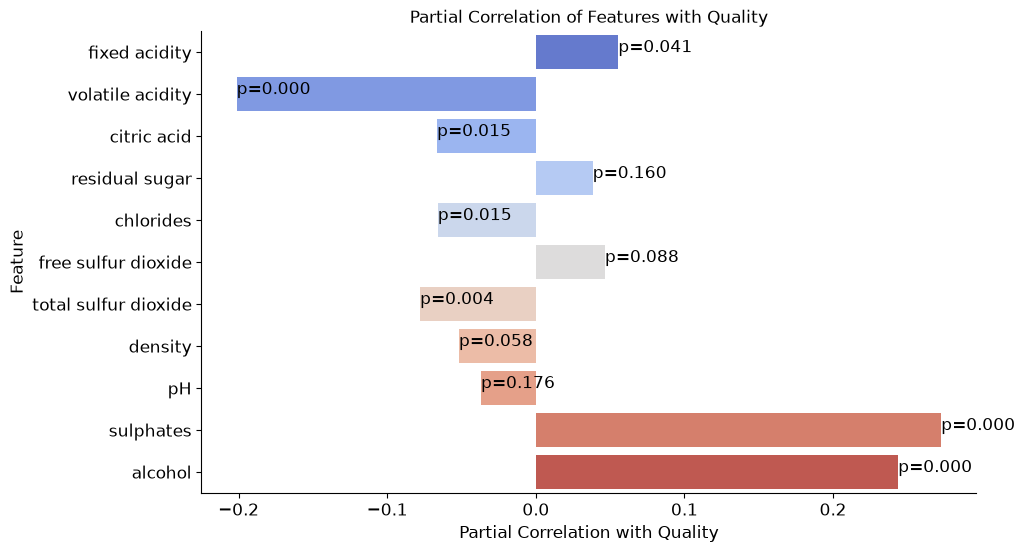

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Partial Correlation with Quality', y='Feature', data=partial_corr_df, hue='Feature', palette='coolwarm', legend=False)

for index, row in partial_corr_df.iterrows():
    plt.text(row['Partial Correlation with Quality'], index, f"p={row['p-value']:.3f}", color='black', ha="left")

sns.despine()
plt.title('Partial Correlation of Features with Quality')
plt.show()


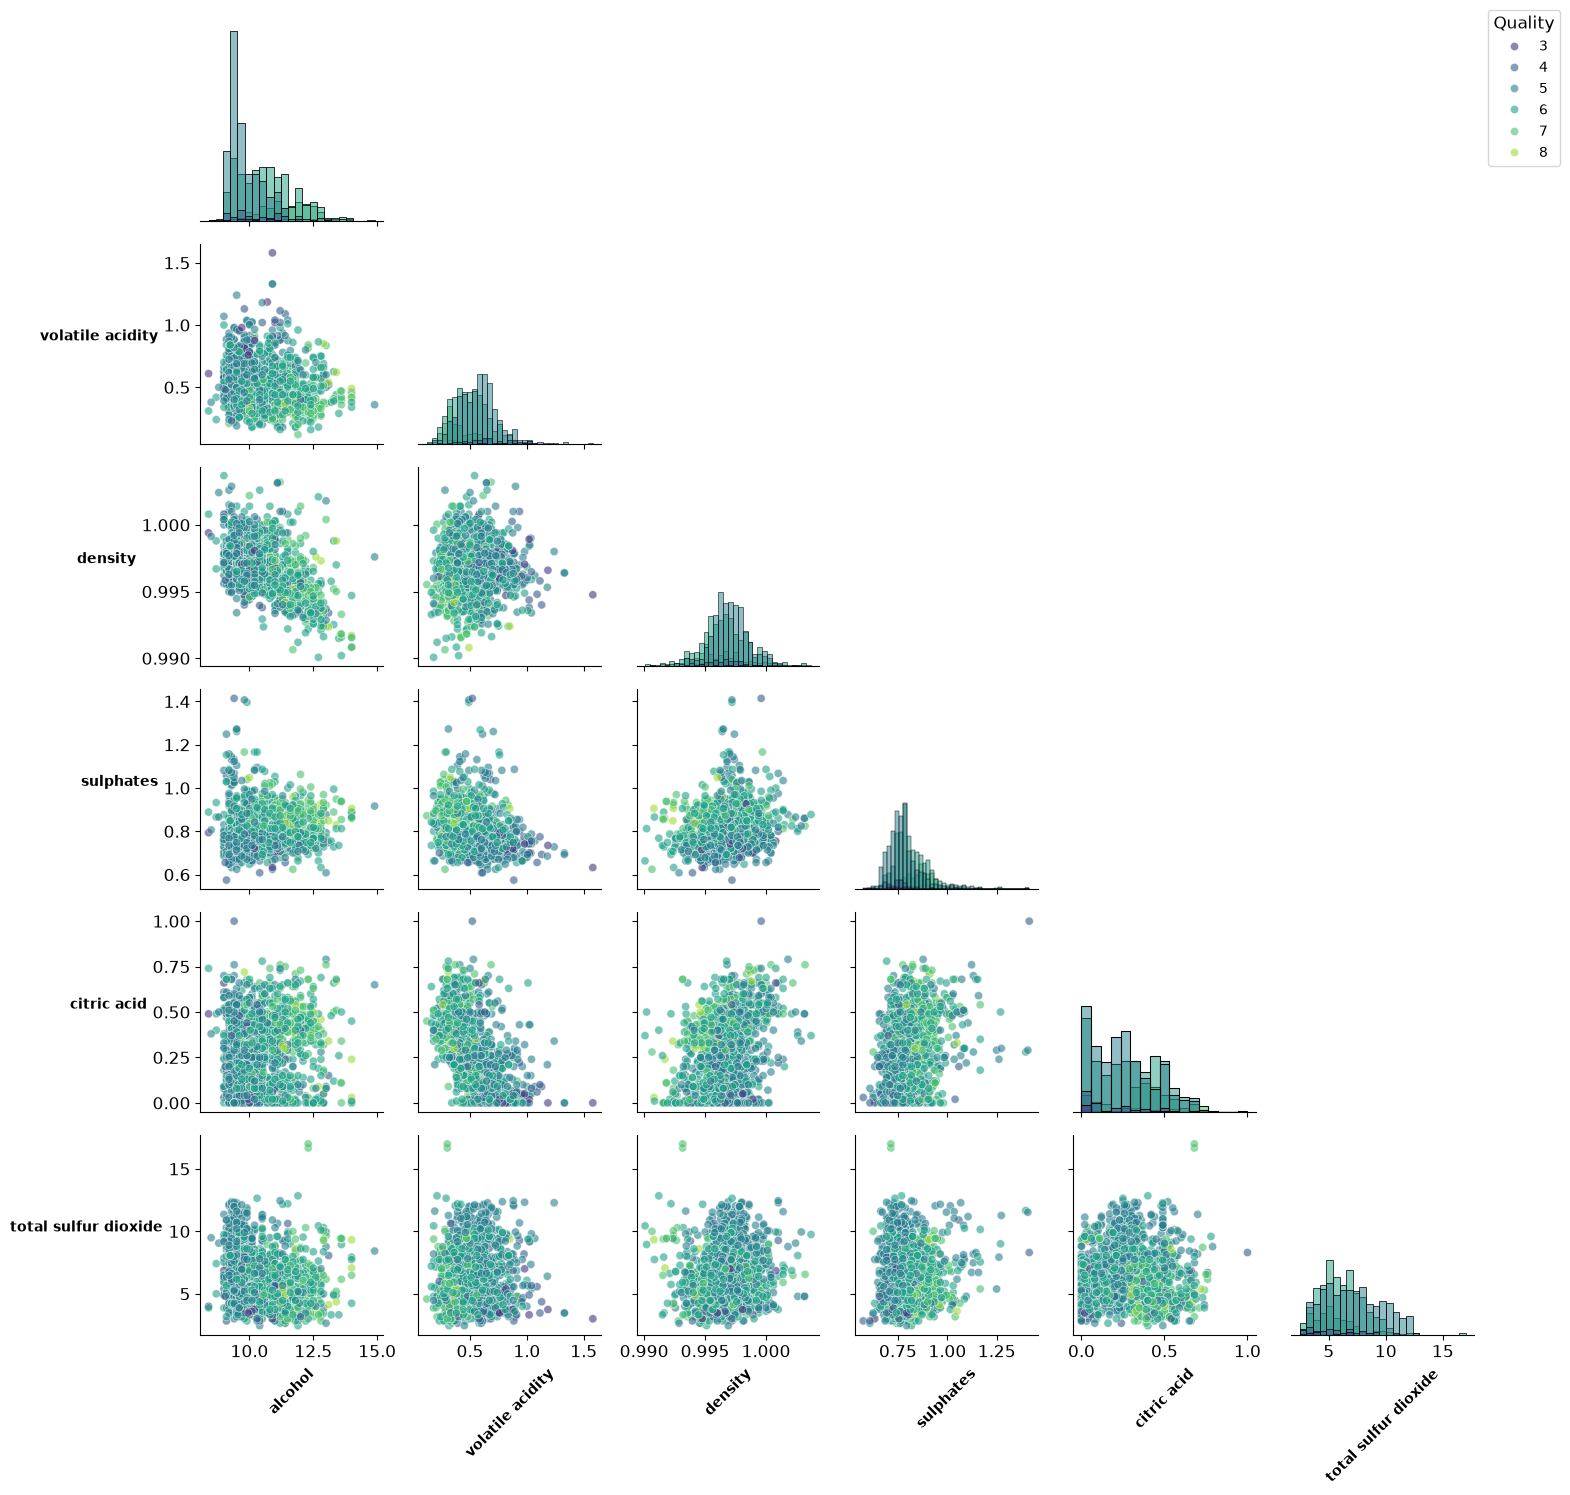

In [30]:

selected_features = ['alcohol', 'volatile acidity', 'density','sulphates','citric acid','total sulfur dioxide']
quality = wine_df2['quality']

palette = sns.color_palette("viridis", as_cmap=False, n_colors=quality.nunique())

g = sns.PairGrid(wine_df2, vars=selected_features, hue='quality', palette=palette , corner = True)

g = g.map_lower(sns.scatterplot, alpha=0.6, edgecolor='w', s=35)
g.map_diag(sns.histplot, kde=False)

for ax in g.axes.flatten():
    if ax:
        ax.set_xlabel(ax.get_xlabel(), rotation=45, fontweight="bold", fontsize=10)
        ax.set_ylabel(ax.get_ylabel(), rotation=0, horizontalalignment='right', fontweight="bold", fontsize=10)

handles = g._legend_data.values()
labels = g._legend_data.keys()
g.fig.legend(handles=handles, labels=labels, title='Quality', loc='upper right', bbox_to_anchor=(1.05, 1), fontsize=10)

plt.tight_layout()
plt.show()

### Scatterplot interpretation

The plots suggest candidate associations to explore. They do not establish interactions or show that one feature offsets the effect of another. The later interaction terms are exploratory model choices.

The scatterplots and correlation tables describe overlapping patterns in the same sample; they are not independent confirmations.

---

# Statistical Analysis


Compare rating groups using rank tests, a mean comparison and effect sizes.

Compare the distributions of measured features between the two rating groups. Multiple tests are exploratory and their unadjusted p-values should not be treated as confirmed discoveries.

In [31]:
def perform_mann_whitney_test(feature):
    high_quality_wines = wine_df2[wine_df2['quality'].isin([7, 8])]
    reg_wines = wine_df2[wine_df2['quality'].isin([3, 4, 5, 6])]
    
    high_quality_values = high_quality_wines[feature].values
    reg_values = reg_wines[feature].values
    
    u_stat, p_value = stats.mannwhitneyu(high_quality_values, reg_values, alternative='two-sided')
    
    n1 = len(high_quality_values)
    n2 = len(reg_values)
    rank_biserial = (2 * u_stat) / (n1 * n2) - 1

    return {
        'feature': feature,
        'u-stat': round(u_stat, 3),
        'p-value': round(p_value, 5),
        'rank_biserial': round(rank_biserial, 3),
        'null_hypothesis': "Reject Null Hypothesis" if p_value < 0.05 else "Fail to Reject Null Hypothesis"
    }

results = [perform_mann_whitney_test(feature) for feature in features]
mann_whitney_results = pd.DataFrame(results)

mann_whitney_results


,feature,u-stat,p-value,rank_biserial,null_hypothesis
0,fixed acidity,130755.5,0.00000,0.210,Reject Null Hypothesis
1,volatile acidity,55030.5,0.00000,-0.491,Reject Null Hypothesis
2,citric acid,144860.0,0.00000,0.340,Reject Null Hypothesis
3,residual sugar,117627.5,0.05382,0.088,Fail to Reject Null Hypothesis
4,chlorides,78361.0,0.00000,-0.275,Reject Null Hypothesis
5,free sulfur dioxide,91720.0,0.00093,-0.152,Reject Null Hypothesis
6,total sulfur dioxide,76678.5,0.00000,-0.291,Reject Null Hypothesis
7,density,79417.0,0.00000,-0.265,Reject Null Hypothesis
8,pH,96480.0,0.01888,-0.107,Reject Null Hypothesis
9,sulphates,160757.5,0.00000,0.487,Reject Null Hypothesis


Read the current table for the group differences and rank-biserial effect sizes. Positive values indicate higher measurements in the group rated 7 or 8; negative values indicate lower measurements. The p-values are unadjusted for multiple testing and do not establish causal effects.

# Statistical Analysis of Alcohol Content in Relation to Wine Quality








Estimate mean alcohol content among records rated at least 7, then compare it with the lower-rated group. The confidence interval relies on sampling assumptions; these observations are not a random sample of all wines.

### **What is the average alcohol percentage in wines rated as 'high quality' (quality rating 7 or above), and what is the 95% confidence interval for this estimate?**

Inspect distribution plots and diagnostic tests. These checks can reveal departures from assumptions but cannot guarantee that all assumptions hold.

In [32]:
high_quality_wines = wine_df2[wine_df2['quality'] >= 7]

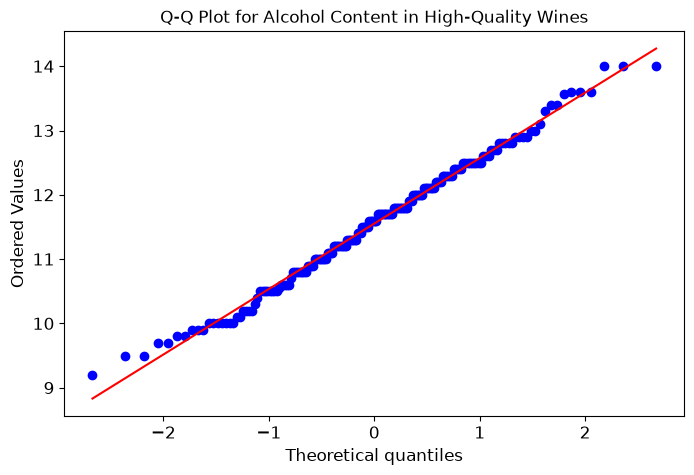

In [33]:
plt.figure(figsize=(8, 5))
stats.probplot(high_quality_wines['alcohol'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Alcohol Content in High-Quality Wines')
plt.show()

In [34]:
shapiro_test_alcohol = stats.shapiro(high_quality_wines['alcohol'])
t, p = shapiro_test_alcohol
print(p)

0.2900548532184163


A Shapiro-Wilk p-value above 0.05 means this test did not detect a departure from normality at that threshold. It does not prove normality.

In [35]:
mean_alcohol = high_quality_wines['alcohol'].mean()
sem_alcohol = stats.sem(high_quality_wines['alcohol'])
ci_alcohol = stats.t.interval(0.95, len(high_quality_wines['alcohol']) - 1,
                              loc=mean_alcohol, scale=sem_alcohol)

            - Standard Error of the Mean (SEM): standard_deviation / sqrt(sample_size)

            - Confidence Interval: Use the t-distribution to find the critical value for a 95% confidence level. The confidence interval can then be calculated as mean ± (critical_value * SEM).

In [36]:
ci_low, ci_high = ci_alcohol

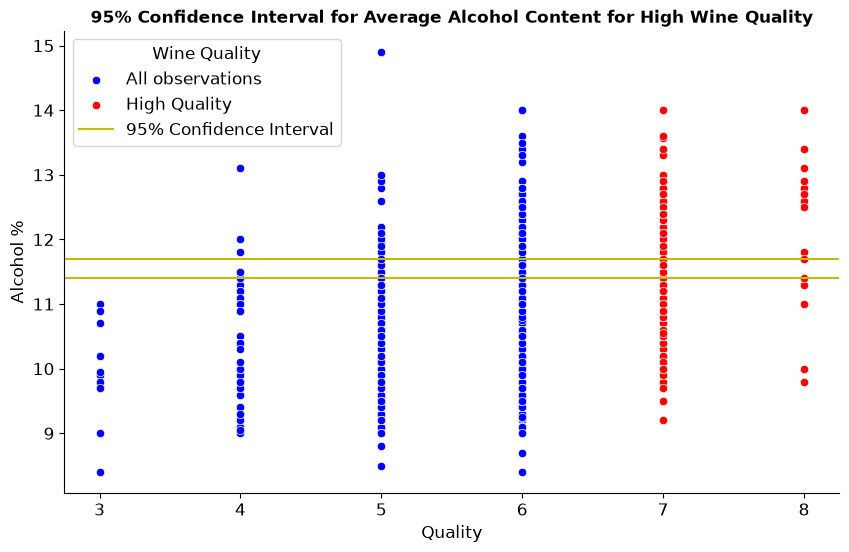

In [37]:
sns.scatterplot(x='quality', 
                y='alcohol',
                data= wine_df2,
                label='All observations',
                color='blue')

sns.scatterplot(x='quality', 
                y='alcohol',
                data= high_quality_wines,
                label='High Quality',
                color='red')
plt.ylabel("Alcohol %")
plt.xlabel("Quality")
plt.axhline(ci_low, color='y', label='95% Confidence Interval')
plt.axhline(ci_high, color='y')
plt.title("95% Confidence Interval for Average Alcohol Content for High Wine Quality", fontweight="bold")
plt.legend(title="Wine Quality")
sns.despine()

In [38]:
print(f'Estimated mean alcohol content: {mean_alcohol:.3f}%; 95% confidence interval: [{ci_low:.3f}, {ci_high:.3f}]')

Estimated mean alcohol content: 11.553%; 95% confidence interval: [11.406, 11.700]


The interval calculated above estimates the mean alcohol content among records rated 7 or higher under the calculation's sampling assumptions. It is not a range of optimal alcohol levels and does not establish what would happen if alcohol content were changed.


----

Looking more comprehensievely at the staitstical significance of wine quality and alochol.

### **Is there a statistically significant difference in the mean alcohol percentage between high-quality and lower-quality wines?**

The null hypothesis is equal population mean alcohol content in the two rating groups. The two-sided alternative is unequal means.

In [39]:
high_quality_alcohol = wine_df2[wine_df2['quality'] >= 7]['alcohol']
lower_quality_alcohol = wine_df2[wine_df2['quality'] < 7]['alcohol']

shapiro_high_quality = stats.shapiro(high_quality_alcohol)
shapiro_lower_quality = stats.shapiro(lower_quality_alcohol)

print("Shapiro-Wilk Test Results:")
print("--------------------------")
print(f"High Quality Wines' Alcohol Percentage:\nStatistic: \n" 
      f"{shapiro_high_quality[0]}, P-value: {shapiro_high_quality[1]}")
print(f"\nLower Quality Wines' Alcohol Percentage:\nStatistic: \n"
      f"{shapiro_lower_quality[0]}, P-value: {shapiro_lower_quality[1]}")

Shapiro-Wilk Test Results:
--------------------------
High Quality Wines' Alcohol Percentage:
Statistic: 
0.9908251793516049, P-value: 0.2900548532184163

Lower Quality Wines' Alcohol Percentage:
Statistic: 
0.9121714664658946, P-value: 1.6523088618887087e-25


Interpret the printed normality tests with the Q-Q plots. A nonsignificant test does not prove normality; group sizes and tail behaviour still matter.

In [40]:
print(f'The sample size for both groups are:\n'
      f'{"-" * 36}\n'
      f'High Quality Wines: {high_quality_alcohol.shape[0]}\n'
      f'Lower Quality Wines: {lower_quality_alcohol.shape[0]}')


The sample size for both groups are:
------------------------------------
High Quality Wines: 184
Lower Quality Wines: 1175


Welch's two-sample t-test compares the group means without assuming equal variances. Independence and the sampling interpretation remain assumptions of this exploratory comparison.

Checking for equal variances :
- Null Hypothesis for Levene's Test: The variances of the two groups are equal.
- Alternative Hypothesis: The variances of the two groups are not equal.

In [41]:
print(f"Equality of Variance test Results\n"
      f'{"-" * 36}\n' 
      f"{stats.levene(high_quality_alcohol, lower_quality_alcohol)}")

Equality of Variance test Results
------------------------------------
LeveneResult(statistic=np.float64(1.0504759289171426), pvalue=np.float64(0.3055801680405939))


A nonsignificant Levene test does not prove equal variances. The comparison below uses Welch's test regardless of the pre-test outcome.

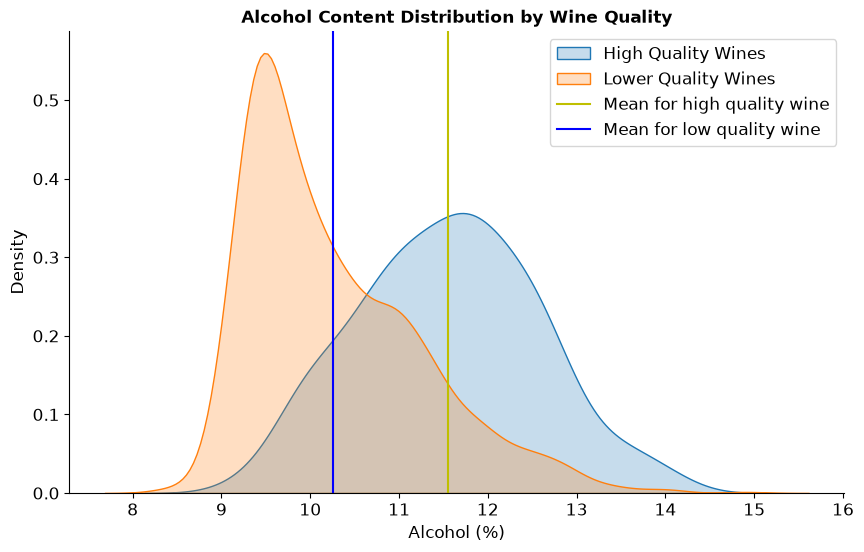

In [42]:
t_stat, p_value = stats.ttest_ind(high_quality_alcohol,
                                  lower_quality_alcohol,
                                  equal_var=False)

plt.figure(figsize=(10, 6))
sns.kdeplot(high_quality_alcohol, label='High Quality Wines', fill=True)
sns.kdeplot(lower_quality_alcohol, label='Lower Quality Wines', fill=True)
plt.title('Alcohol Content Distribution by Wine Quality', fontweight = "bold")
plt.axvline(high_quality_alcohol.mean(), label = "Mean for high quality wine", color = 'y')
plt.axvline(lower_quality_alcohol.mean(), label = "Mean for low quality wine", color ='b')
plt.xlabel('Alcohol (%)')
plt.ylabel('Density')
sns.despine()
plt.legend()
plt.show()

In [43]:

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 16.20951686195764, P-value: 2.0005604539238566e-40


Interpret the printed Welch-test p-value at the stated 0.05 threshold, subject to the observational sampling assumptions. Statistical significance does not imply causation.

Looking at the effect size

In [44]:
mean_high_quality = np.mean(high_quality_alcohol)
mean_lower_quality = np.mean(lower_quality_alcohol)

std_high_quality = np.std(high_quality_alcohol, ddof=1)
std_lower_quality = np.std(lower_quality_alcohol, ddof=1)

n_high, n_lower = len(high_quality_alcohol), len(lower_quality_alcohol)
pooled_std = np.sqrt(((n_high - 1) * std_high_quality**2 + (n_lower - 1) * std_lower_quality**2) / (n_high + n_lower - 2))

cohens_d = (mean_high_quality - mean_lower_quality) / pooled_std

print(f"Cohen's d: {cohens_d}")

Cohen's d: 1.3125795361091273


The printed Cohen's d uses a sample-size-weighted pooled standard deviation. It describes the sample's standardised mean difference; practical importance requires context beyond this statistic.

These are observational associations. They do not support a recommendation for consumers to select a particular alcohol range or for winemakers to change alcohol content to improve quality.


---

# Predicting wine quality 
 ### Regression Analysis

- **Modeling**

In [45]:
X_train_base_model, X_test_base_model, y_train_base_model, y_test_base_model = preprocess_data(wine_df2, 'quality', stratify = True)
base_model, vif_base = fit_and_evaluate_model(X_train_base_model, y_train_base_model)

print("Model with All Features:")
print(base_model.summary())

Model with All Features:
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     56.22
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           3.42e-98
Time:                        23:33:11   Log-Likelihood:                -1085.4
No. Observations:                1087   AIC:                             2195.
Df Residuals:                    1075   BIC:                             2255.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const  

Checking for multicollinearity 

In [46]:
print(vif_base.sort_values(by="VIF", ascending=False))

                 feature       VIF
1          fixed acidity  8.276808
8                density  7.129180
9                     pH  3.445130
11               alcohol  3.383589
3            citric acid  3.236196
7   total sulfur dioxide  2.817877
6    free sulfur dioxide  2.495362
4         residual sugar  1.788744
2       volatile acidity  1.782079
5              chlorides  1.445280
10             sulphates  1.401507
0                  const  1.000000


Read the VIF table to assess correlation among predictors; no single cutoff establishes that a model is suitable.

In [47]:
y_pred_b = base_model.predict(X_test_base_model)
test_mse_b = mean_squared_error(y_test_base_model, y_pred_b)
test_r2_b = r2_score(y_test_base_model, y_pred_b)

In [48]:
print(test_mse_b,test_r2_b)

0.4224097661768591 0.3703216912649605


### Diagnostic Plot
- check for linearity
- check for homoskedasticity 

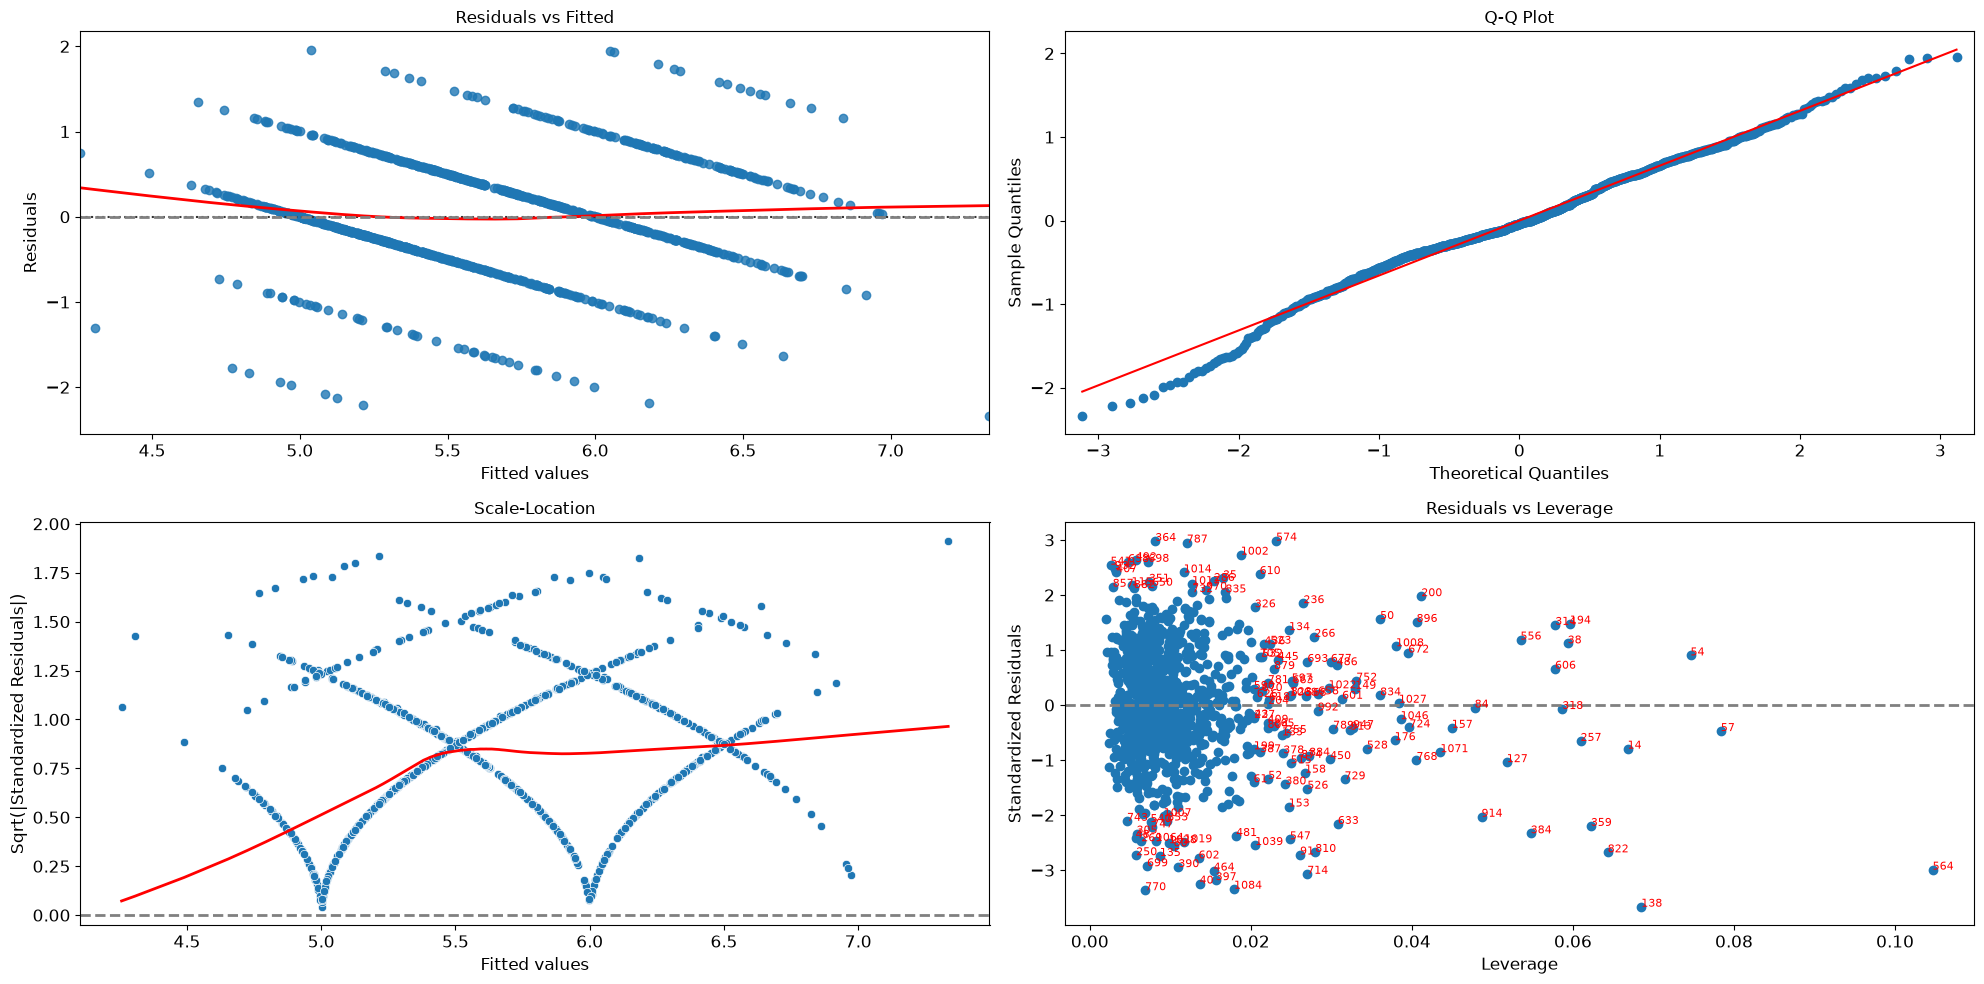

In [49]:
plot_diagnostic_plots(base_model)

Inspect curvature, changing residual spread and tail departures in these diagnostics. The Q-Q reference line accounts for the residual scale; deviations from it concern distribution shape. The ordinal response also creates visible bands in residual plots.

In [50]:
summary_info = base_model.get_influence().summary_frame()

X_train_base_model["leverage"] = summary_info["hat_diag"]
X_train_base_model["cooks_dist"] = summary_info["cooks_d"]

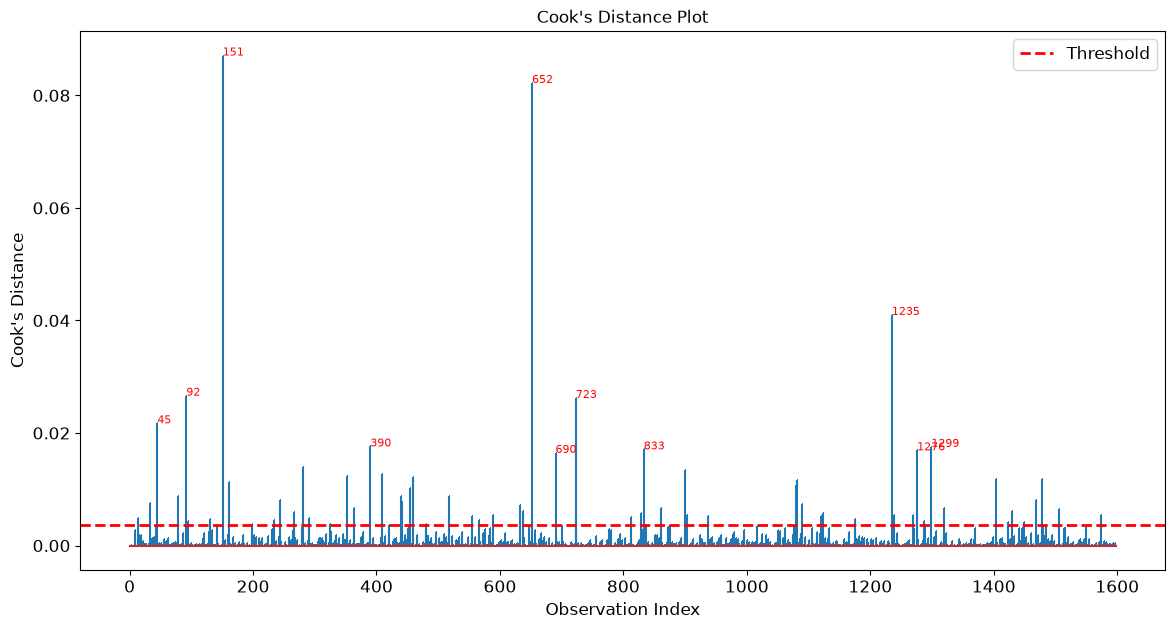

In [51]:
plot_cooks_distance(summary_info)

In [52]:
X_train_base_model.sort_values(by = "cooks_dist", ascending = False).head(10)

,const,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,leverage,cooks_dist
151,1.0,0.486587,-0.064707,3.700386,0.877860,8.429332,1.465679,0.788662,1.508593,-3.580926,6.384658,-0.951996,0.104670,0.087083
652,1.0,4.232642,-0.926747,1.919157,3.624061,0.346059,0.705690,0.840169,0.466571,-2.069411,1.174873,4.064685,0.068486,0.082218
1235,1.0,-1.302573,-1.088379,0.239713,6.242391,-0.982774,-1.056532,1.789933,-0.512930,-0.054057,-0.585632,0.963464,0.064314,0.040993
92,1.0,0.151120,-0.226340,0.087037,-0.441045,0.720450,0.444991,2.178810,0.258166,-2.384310,6.310454,-0.587147,0.062220,0.026638
723,1.0,-0.687549,-1.196134,0.137929,-0.229176,-1.019858,1.735522,2.065418,-0.106541,-2.321330,4.904294,-0.860784,0.054749,0.026219
45,1.0,-2.085331,-0.064707,-0.625455,-0.333849,-0.982774,-0.758543,0.683358,-1.721675,3.724731,-0.585632,2.422862,0.027000,0.021724
390,1.0,-1.526218,1.713249,-1.134377,-1.150068,-1.330113,-0.258660,1.251568,-2.242686,1.583418,1.059973,2.240437,0.023132,0.017610
1299,1.0,-0.407993,5.646305,-1.388839,-0.333849,1.380454,-1.224363,-1.498112,-1.013100,1.205539,-1.798593,0.416190,0.048646,0.017537
833,1.0,1.828458,-0.334095,0.850420,-0.899313,1.608114,1.735522,0.286546,0.862539,0.449781,1.288414,-0.495934,0.027990,0.017079
1276,1.0,0.095209,-0.711237,0.646851,2.922297,-1.133262,-1.620713,-1.428182,-0.544190,-0.180017,-0.585632,1.419526,0.017915,0.016918


## Model 2 without highest influential points

- Removing the most influential points 

In [53]:
most_influential_points = X_train_base_model[X_train_base_model['cooks_dist']> 0.02].index

- train and test datasets

In [54]:
X_train_base_cleaned = X_train_base_model.drop(index=most_influential_points)
y_train_model_2 = y_train_base_model.drop(index=most_influential_points)

X_train_model_2 = X_train_base_cleaned.drop(columns=['leverage', 'cooks_dist'])


In [55]:
X_test_model_2 = X_test_base_model.copy()
y_test_model_2 = y_test_base_model.copy()

**Modelling**

In [56]:
base_model_2, vif_model_2 = fit_and_evaluate_model(X_train_model_2, y_train_model_2)

In [57]:
base_model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     61.45
Date:                Tue, 08 Sep 2026   Prob (F-statistic):          9.37e-106
Time:                        23:33:21   Log-Likelihood:                -1056.4
No. Observations:                1081   AIC:                             2137.
Df Residuals:                    1069   BIC:                             2197.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6365      0.020    286.546      0.000       5.598       5.675
fixed acidity            0.0378      0.058      0.651      0.515      -0.076       0.152
volatile acidity        -0.1829      0.026     -6.947      0.000      -0.235      -0.131
citric acid             -0.0072      0.036     -0.202      0.840      -0.077       0.063
residual sugar           0.0034      0.027      0.125      0.901      -0.050       0.056
chlorides               -0.0795      0.024     -3.304      0.001      -0.127      -0.032
free sulfur dioxide      0.0518      0.032      1.643      0.101      -0.010       0.114
total sulfur dioxide    -0.0712      0.034     -2.123      0.034      -0.137      -0.005
density                 -0.0325      0.053     -0.613      0.540      -0.136       0.071
pH                      -0.0659      0.037     -1.769      0.077      -0.139       0.007
sulphates                0.1925      0.024      7.937      0.000       0.145       0.240
alcohol                  0.3105      0.036      8.590      0.000       0.240       0.381
==============================================================================
Omnibus:                       11.594   Durbin-Watson:                   1.901
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               14.662
Skew:                          -0.140   Prob(JB):                     0.000655
Kurtosis:                       3.497   Cond. No.                         7.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Compare training fit with the earlier model. Removing influential training observations changes the sample and can improve fit without improving generalisation.

In [58]:
model_results = pd.DataFrame(columns= ['Model_Name', 'Model_Description', 'Adj_R_squared', 'AIC', 'BIC'])

model_results = extract_and_rank_model_metrics(base_model, 'base_model', 'Base model with all features', model_results)
model_results = extract_and_rank_model_metrics(base_model_2, 'base_model_2', 'Model after removing most influential points', model_results)


In [59]:
display(model_results)

,Model_Name,Model_Description,Adj_R_squared,AIC,BIC
0,base_model,Base model with all features,0.358701,2194.769586,2254.663709
1,base_model_2,Model after removing most influential points,0.381079,2136.848961,2196.676663


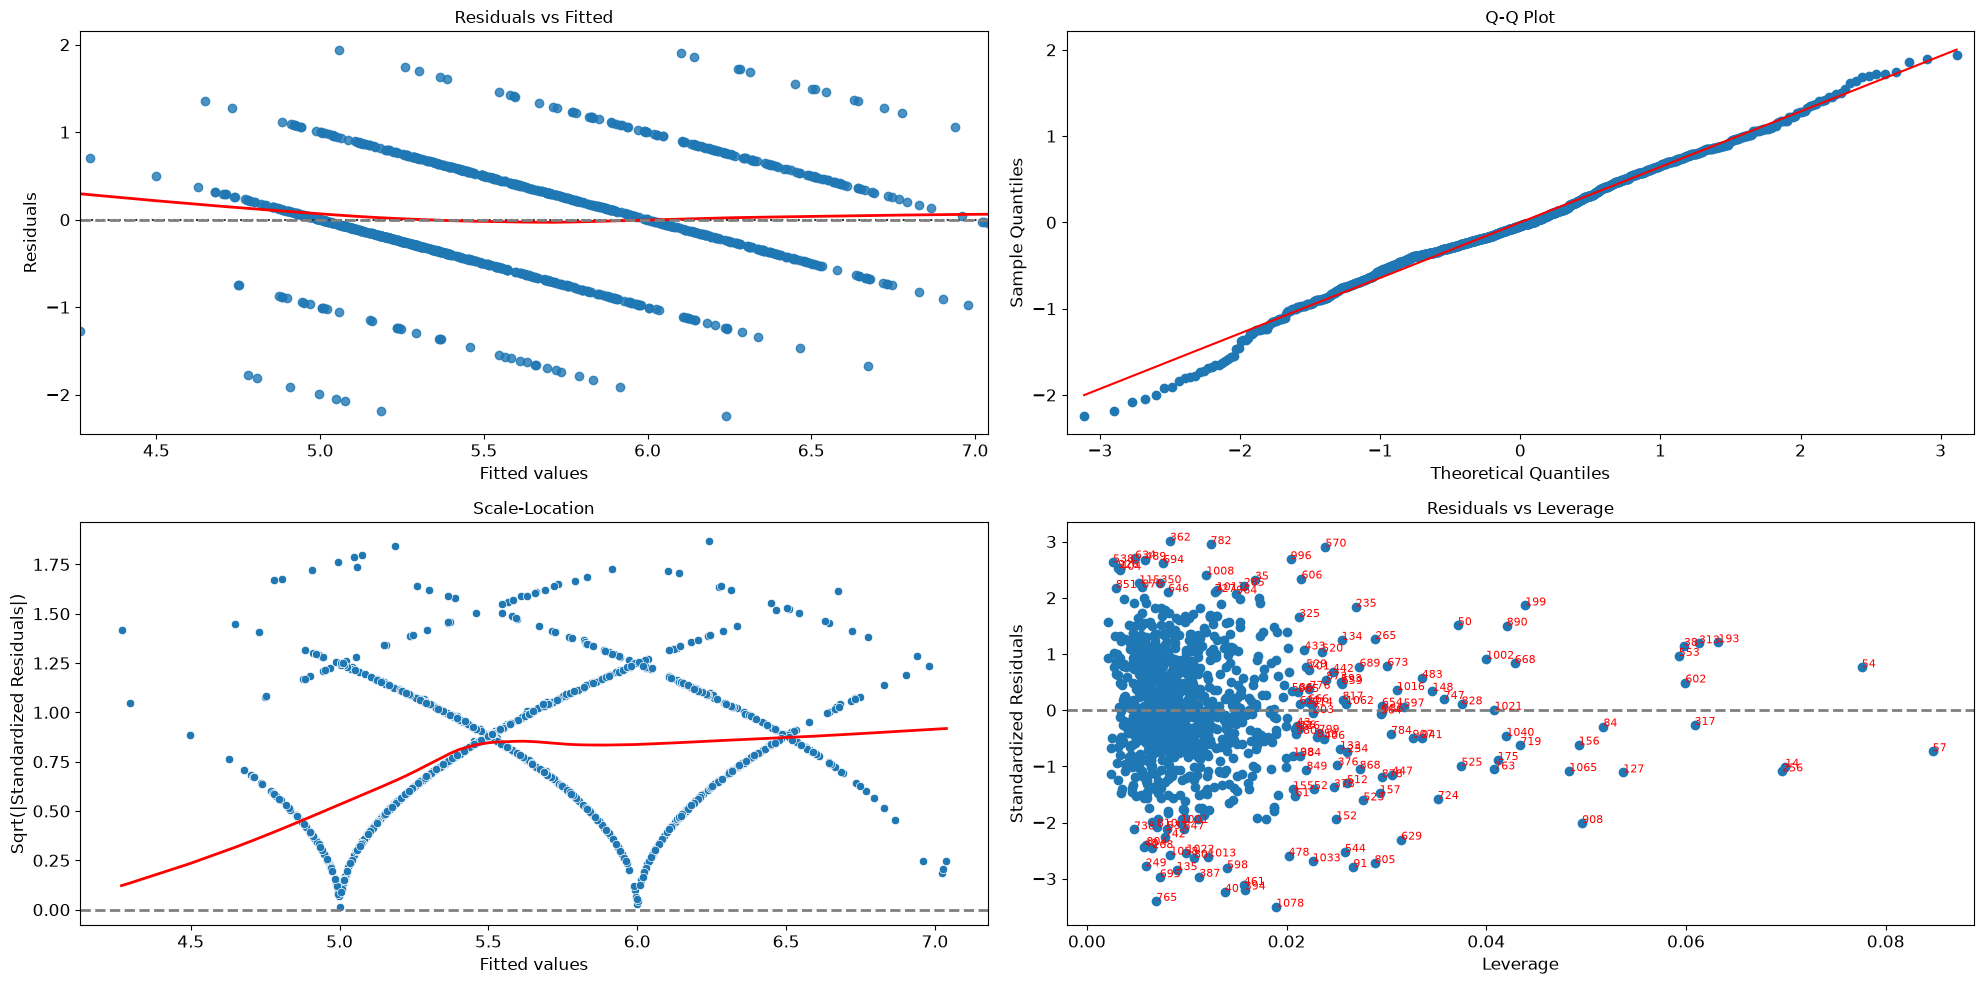

In [60]:
plot_diagnostic_plots(base_model_2)

Removing influential rows changes the fitted sample. Inspect the remaining residual patterns rather than assuming this resolves model misspecification.

## Transformed response variable

In [61]:
df2 = wine_df2.copy()

In [62]:
df2['log_quality'] = np.log(df2['quality'])
df2['sqrt_quality'] = np.sqrt(df2['quality'])
from sklearn.model_selection import train_test_split
box_train_index, _ = train_test_split(df2.index, test_size=0.2, random_state=42)
_, boxcox_lambda = stats.boxcox(df2.loc[box_train_index, 'quality'])
df2['boxcox_quality'] = stats.boxcox(df2['quality'], lmbda=boxcox_lambda)

In [63]:
quality_features = [name for name in df2.columns if "quality" in name]
print(quality_features)

['quality', 'log_quality', 'sqrt_quality', 'boxcox_quality']


In [64]:
X_train_log, X_test_log, y_train_log, y_test_log = preprocess_data(df2, target_variable = 'log_quality', drop_features= quality_features)
model_log, vif_log = fit_and_evaluate_model(X_train_log, y_train_log)
print('log transformed model')
print(model_log.summary())

log transformed model
                            OLS Regression Results                            
Dep. Variable:            log_quality   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     49.94
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           1.30e-88
Time:                        23:33:26   Log-Likelihood:                 764.61
No. Observations:                1087   AIC:                            -1505.
Df Residuals:                    1075   BIC:                            -1445.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const     

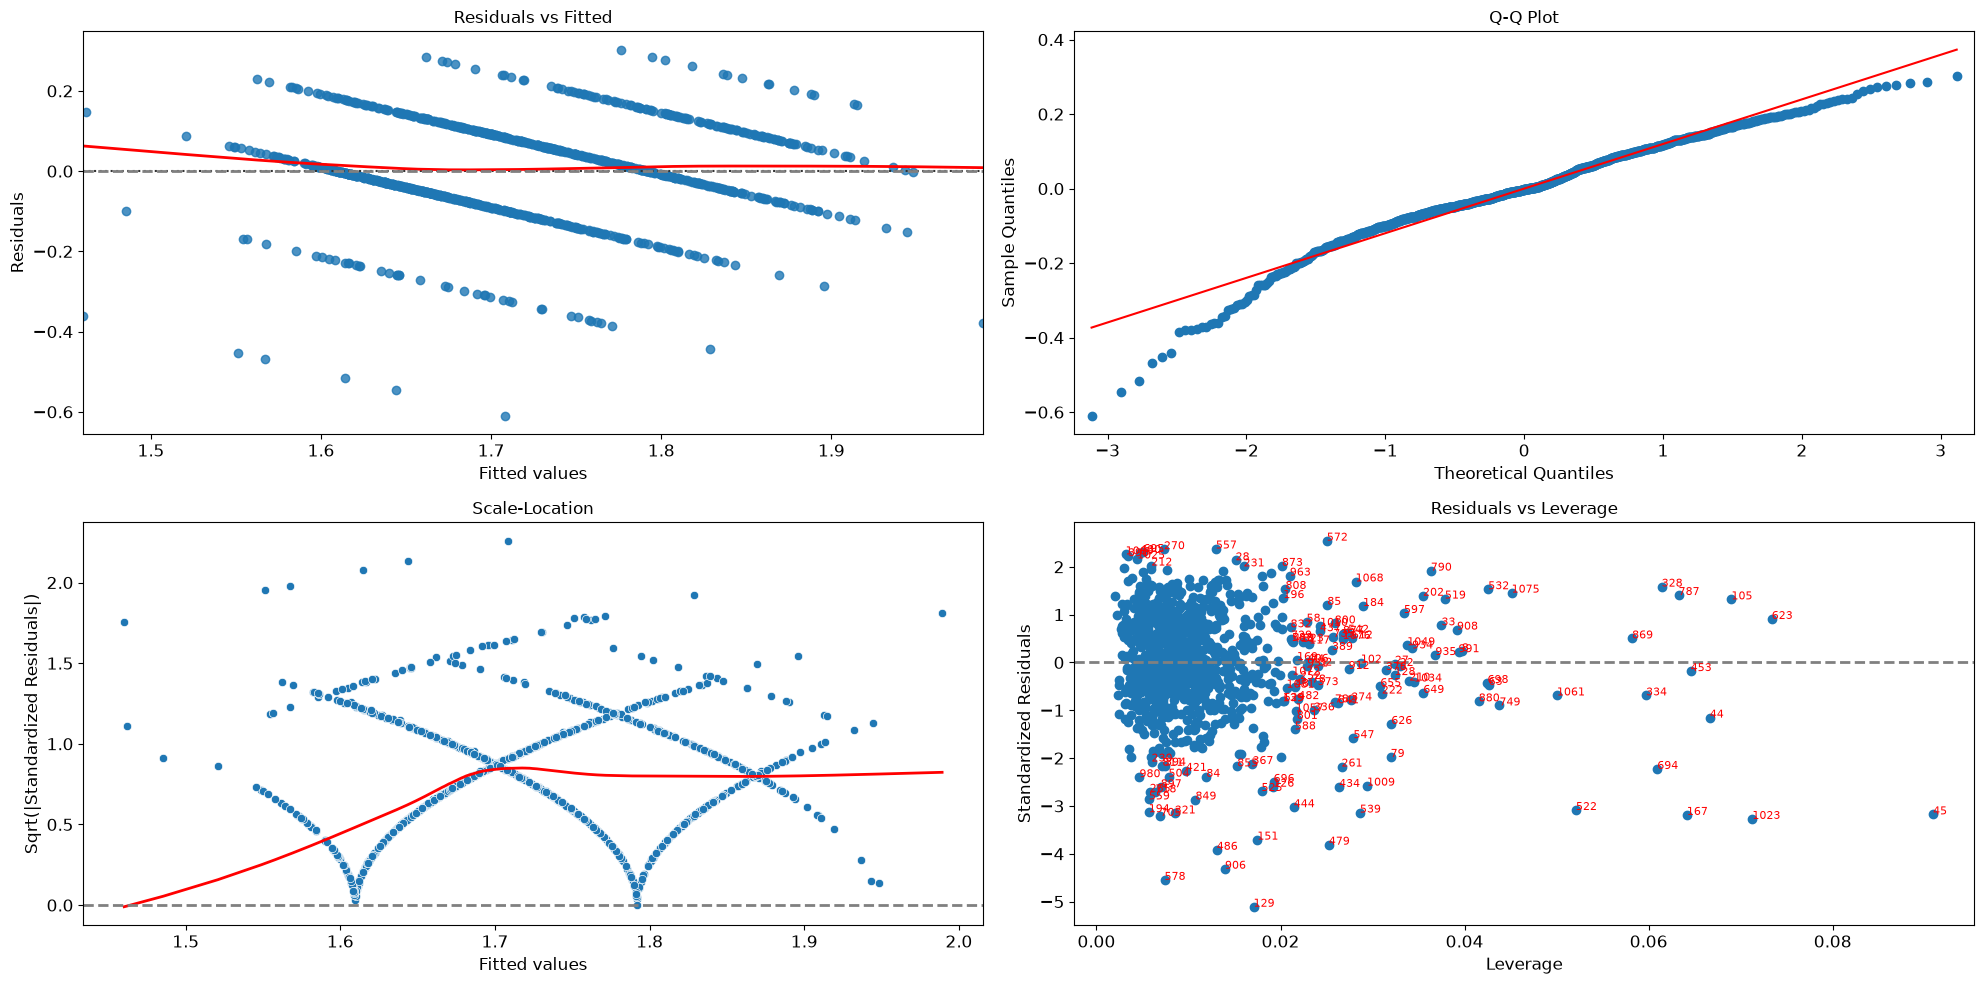

In [65]:
plot_diagnostic_plots(model_log)

square root transformed model
                            OLS Regression Results                            
Dep. Variable:           sqrt_quality   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     52.34
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           2.57e-92
Time:                        23:33:32   Log-Likelihood:                 600.08
No. Observations:                1087   AIC:                            -1176.
Df Residuals:                    1075   BIC:                            -1116.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

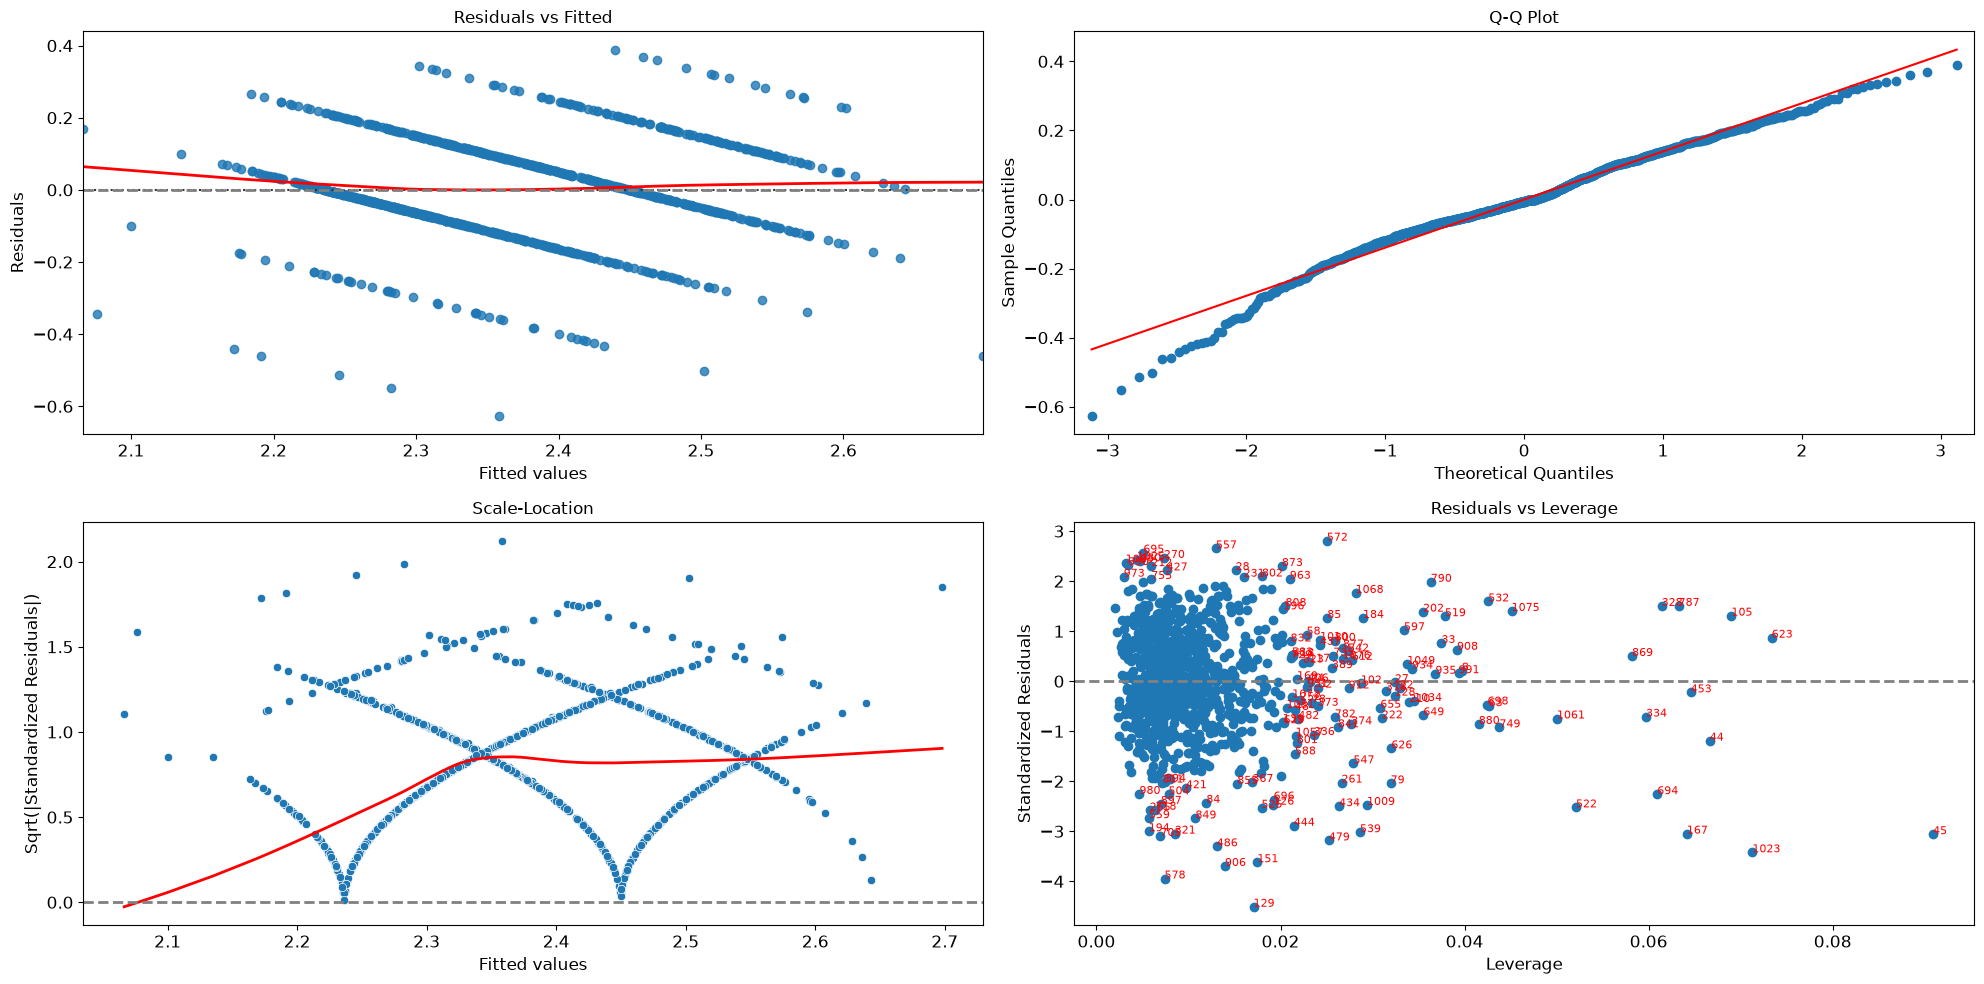

In [66]:
X_train_sqrt, X_test_sqrt, y_train_sqrt, y_test_sqrt = preprocess_data(df2, target_variable = 'sqrt_quality', drop_features= quality_features)
model_sqrt, vif_sqrt = fit_and_evaluate_model(X_train_sqrt, y_train_sqrt)
print('square root transformed model')
print(model_sqrt.summary())


plot_diagnostic_plots(model_sqrt)

Box Cox transformed model
                            OLS Regression Results                            
Dep. Variable:         boxcox_quality   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     52.66
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           8.29e-93
Time:                        23:33:38   Log-Likelihood:                -296.77
No. Observations:                1087   AIC:                             617.5
Df Residuals:                    1075   BIC:                             677.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const 

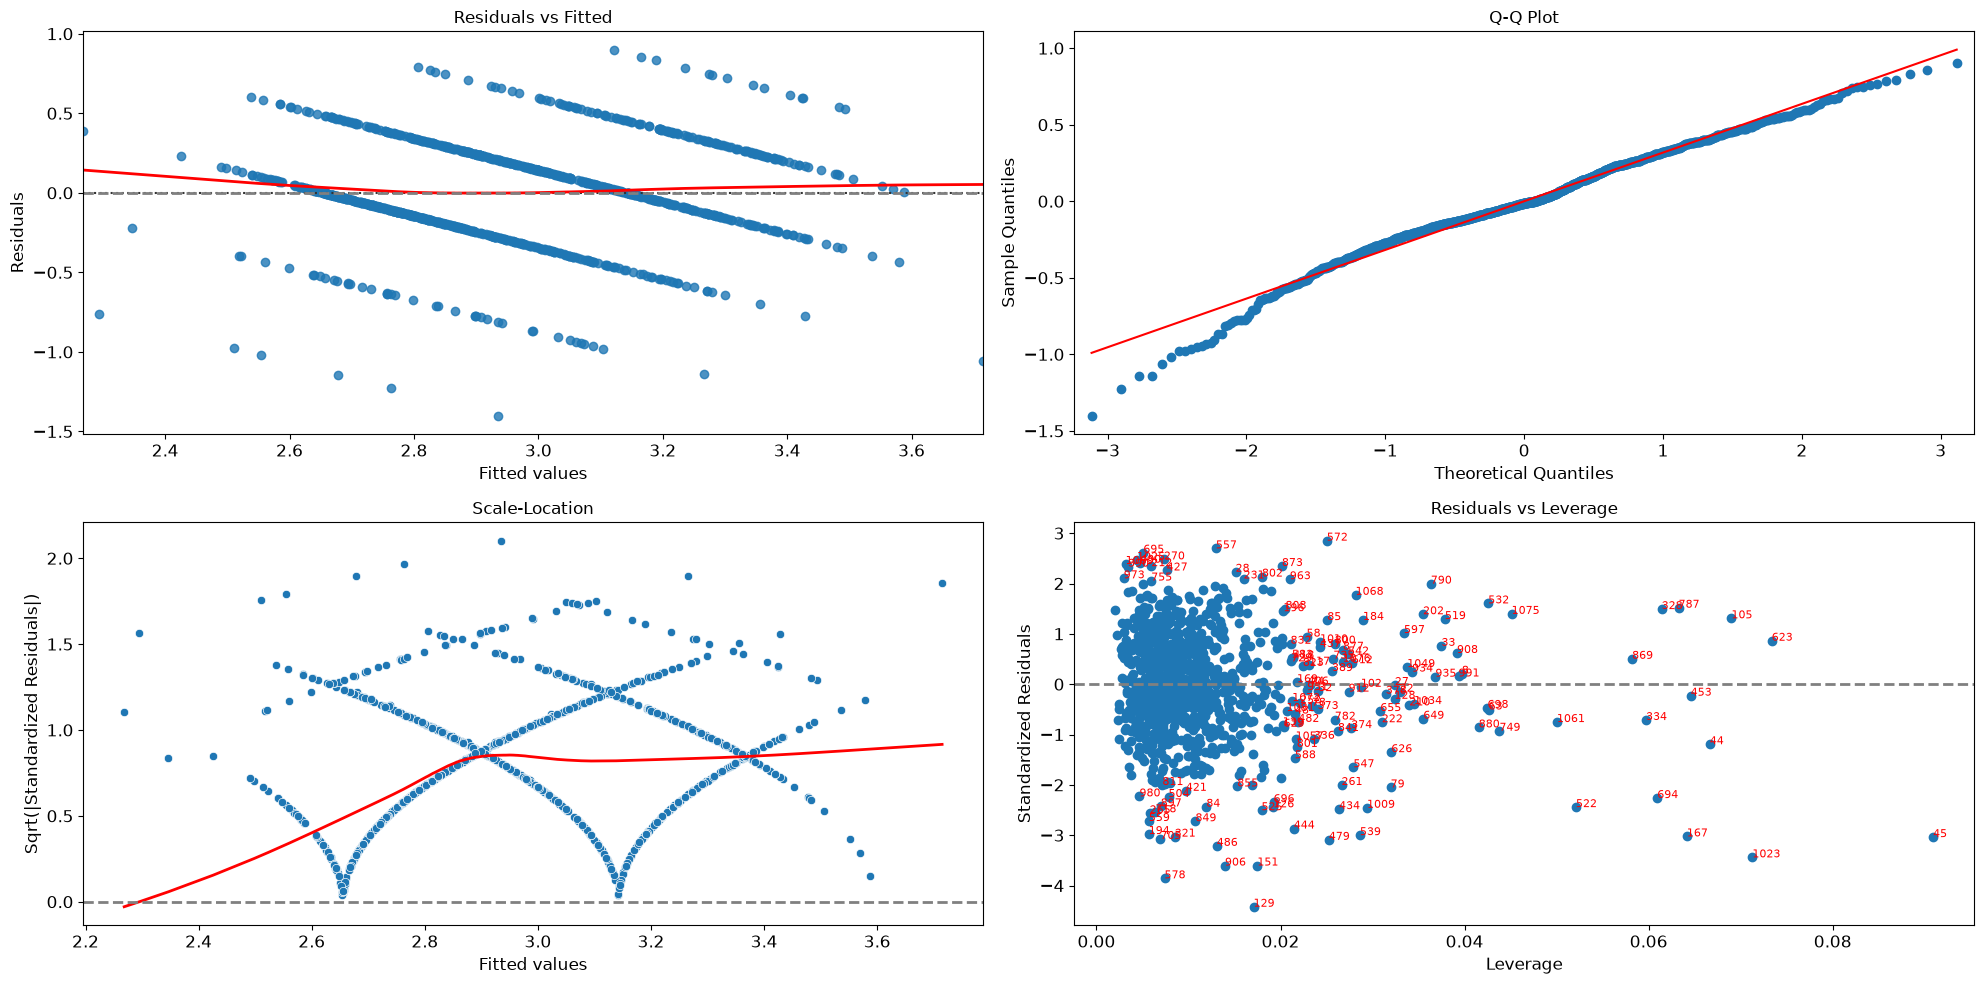

In [67]:
X_train_box, X_test_box, y_train_box, y_test_box = preprocess_data(df2, target_variable = 'boxcox_quality', drop_features= quality_features)
model_box, vif_box = fit_and_evaluate_model(X_train_box, y_train_box)
print('Box Cox transformed model')
print(model_box.summary())


plot_diagnostic_plots(model_box)

Log, square-root and Box-Cox target transformations are exploratory alternatives. Box-Cox uses a parameter fitted only on its training rows. The following models return to the original ordinal quality scale; transformed-target training diagnostics should not be ranked against original-scale models.

###  Addressing Potential non-linearity 

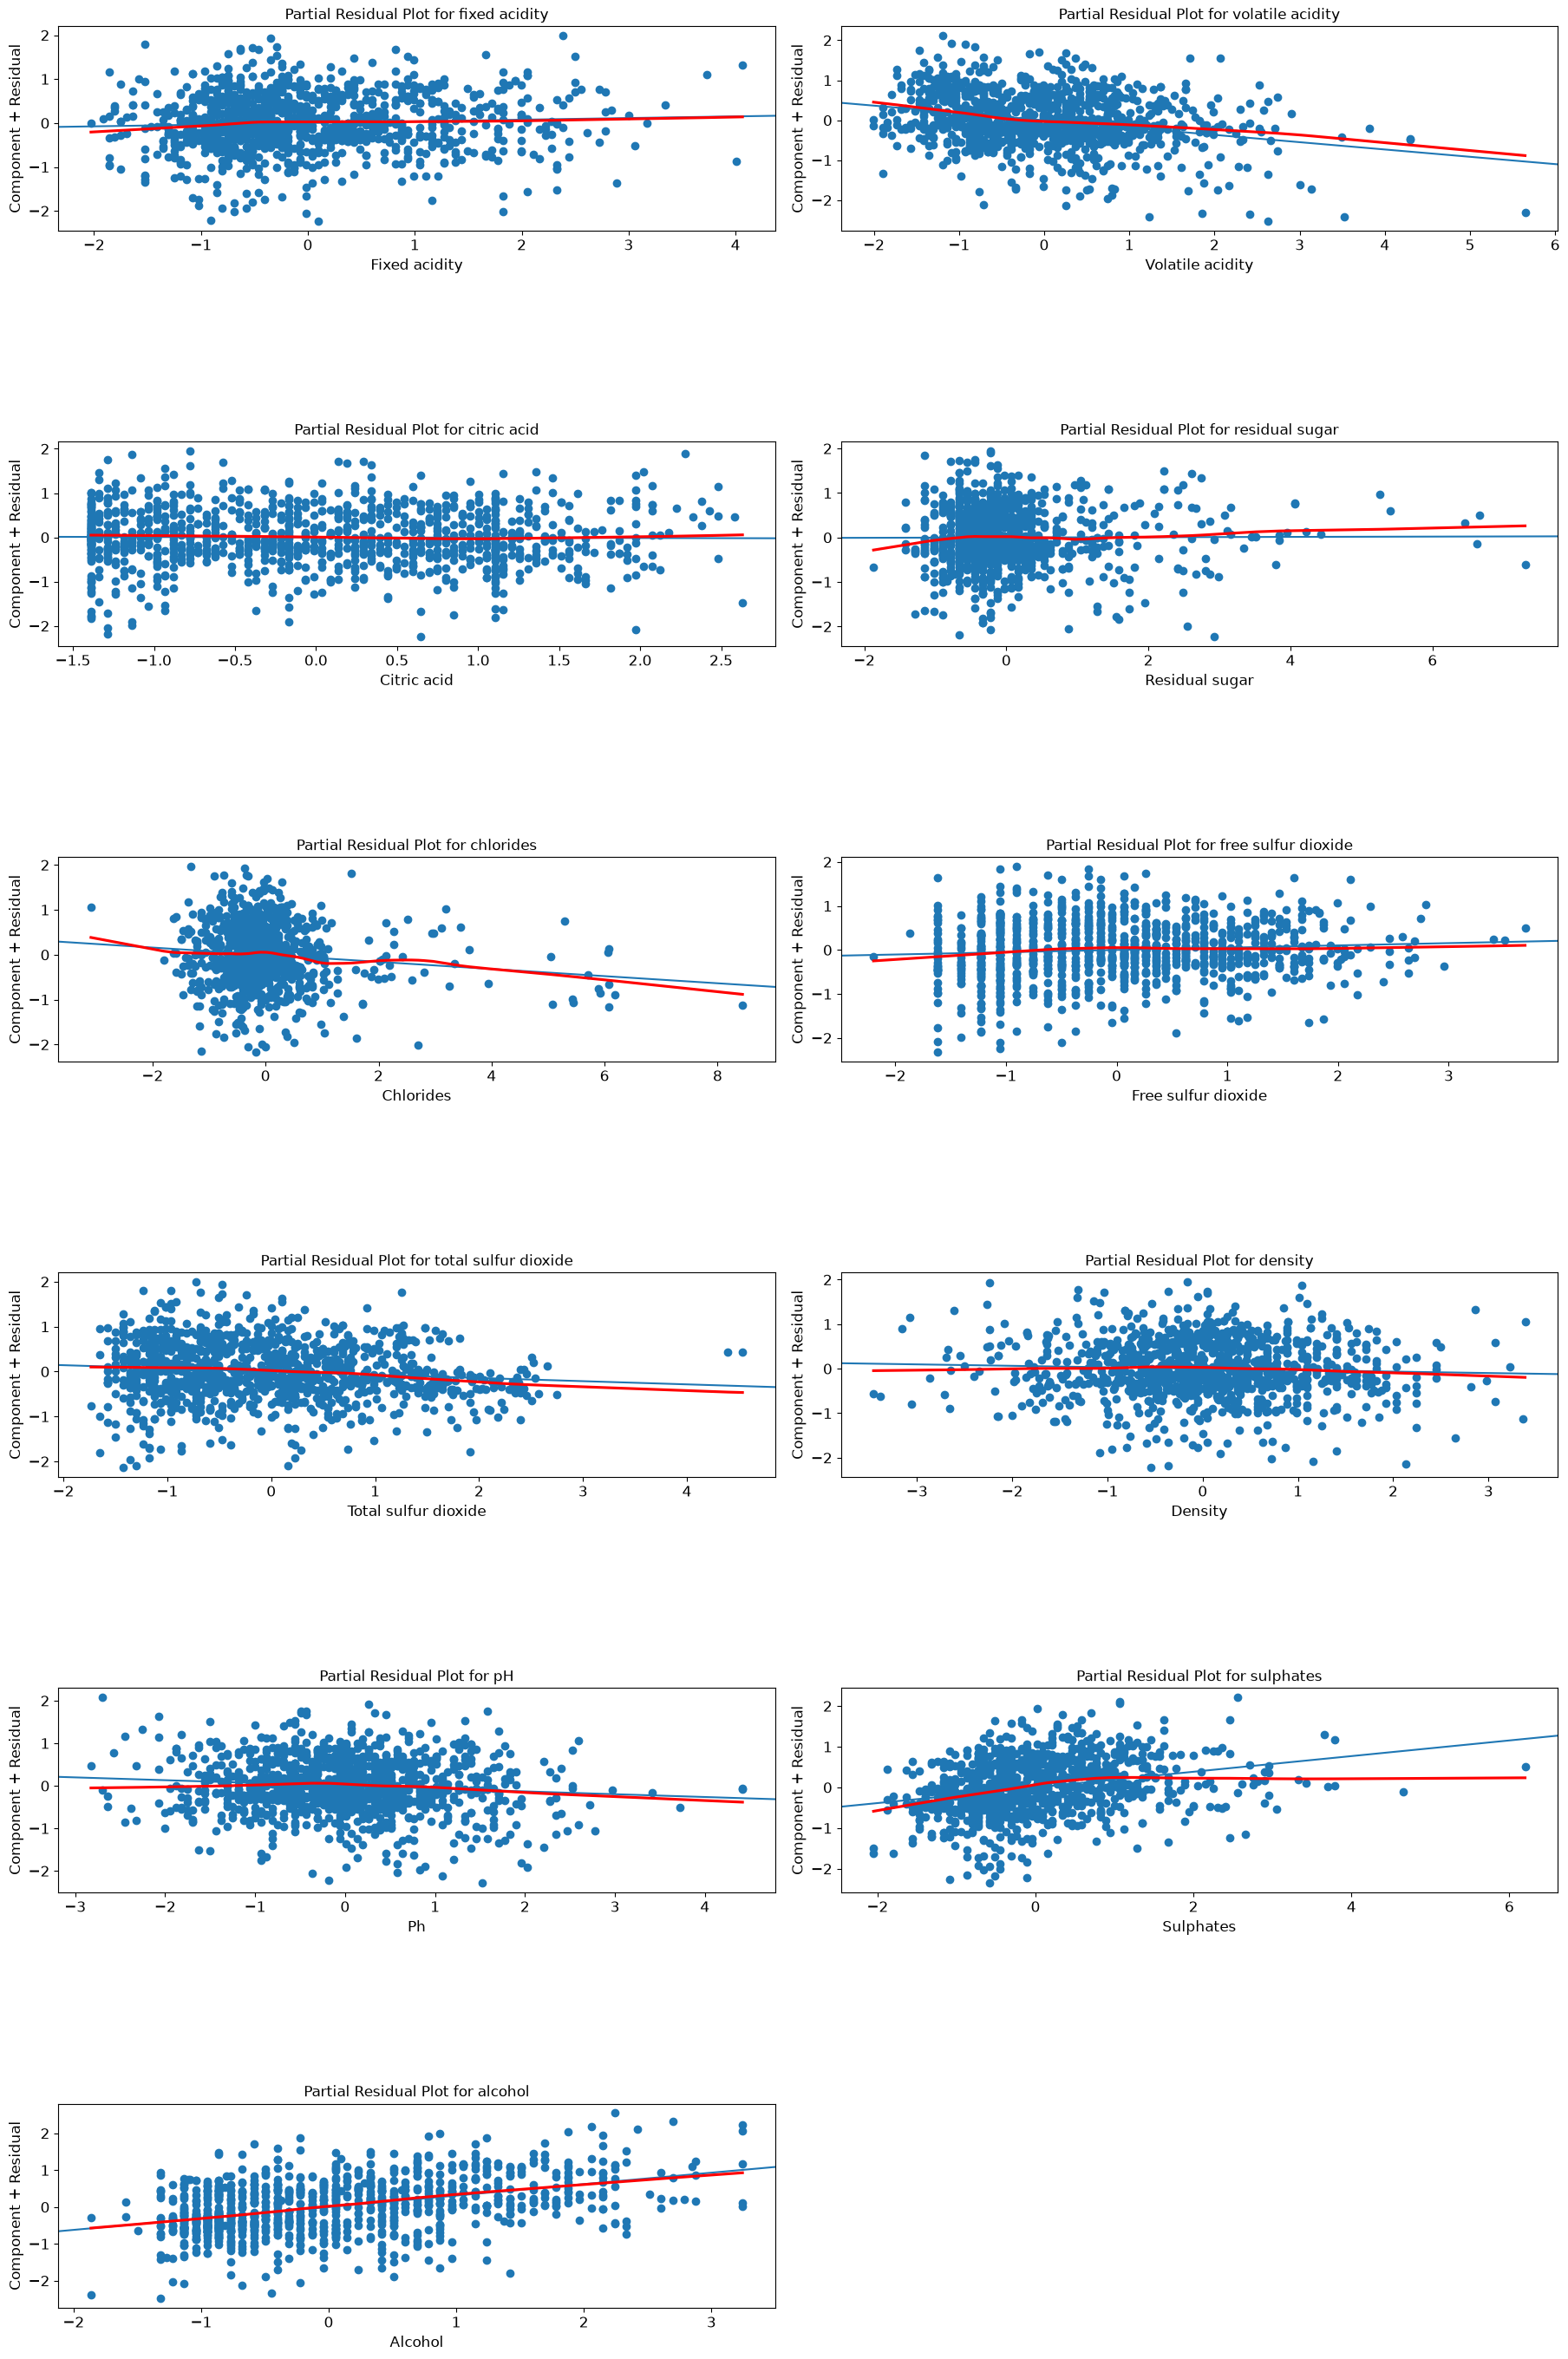

In [68]:
generate_partial_residual_plots(base_model_2, X_train_model_2)

The sulphates partial-residual plot motivates an exploratory polynomial term. This visual choice is not an independently validated relationship.

------

### Adding Polynomial and Interaction Terms

- Interaction terms are selected based on features that demonstrate the strongest partial correlations in the bivariate analysis.
- Polynomial terms are identified by insights gained from the partial residual plots.

In [69]:
X_train_model_3 = X_train_model_2.copy()
X_test_model_3 = X_test_model_2.copy()

In [70]:
poly = PolynomialFeatures(degree=2, include_bias=False)
sulphates_poly = poly.fit_transform(X_train_model_3[['sulphates']])

In [71]:
X_train_model_3['sulphates^2'] = sulphates_poly[:, 1]

In [72]:
sulphates_poly_test = poly.transform(X_test_model_3[['sulphates']])
X_test_model_3['sulphates^2'] = sulphates_poly_test[:, 1]

- **Adding interaction terms**

In [73]:
X_train_model_3['volatile_acidity*sulphates'] = X_train_model_2['volatile acidity'] * X_train_model_2['sulphates']
X_train_model_3['volatile_acidity*alcohol'] = X_train_model_2['volatile acidity'] * X_train_model_2['alcohol']
X_train_model_3['sulphates*alcohol'] = X_train_model_2['sulphates'] * X_train_model_2['alcohol']


In [74]:
X_test_model_3['volatile_acidity*sulphates'] = X_test_model_3['volatile acidity'] * X_test_model_3['sulphates']
X_test_model_3['volatile_acidity*alcohol'] = X_test_model_3['volatile acidity'] * X_test_model_3['alcohol']
X_test_model_3['sulphates*alcohol'] = X_test_model_3['sulphates'] * X_test_model_3['alcohol']


In [75]:
base_model_3, vif_all_base_model_3 = fit_and_evaluate_model(X_train_model_3, y_train_model_2)


In [76]:
base_model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     48.95
Date:                Tue, 08 Sep 2026   Prob (F-statistic):          4.76e-110
Time:                        23:34:06   Log-Likelihood:                -1037.9
No. Observations:                1081   AIC:                             2108.
Df Residuals:                    1065   BIC:                             2187.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          5.6740      0.024    239.198      0.000       5.628       5.721
fixed acidity                  0.0393      0.058      0.680      0.496      -0.074       0.153
volatile acidity              -0.1706      0.027     -6.334      0.000      -0.223      -0.118
citric acid                   -0.0124      0.035     -0.352      0.725      -0.082       0.057
residual sugar                 0.0121      0.027      0.455      0.649      -0.040       0.064
chlorides                     -0.0499      0.024     -2.047      0.041      -0.098      -0.002
free sulfur dioxide            0.0373      0.031      1.194      0.233      -0.024       0.099
total sulfur dioxide          -0.0658      0.033     -1.967      0.049      -0.131      -0.000
density                       -0.0770      0.053     -1.448      0.148      -0.181       0.027
pH                            -0.0872      0.038     -2.300      0.022      -0.162      -0.013
sulphates                      0.2750      0.029      9.532      0.000       0.218       0.332
alcohol                        0.2756      0.036      7.560      0.000       0.204       0.347
sulphates^2                   -0.0547      0.013     -4.278      0.000      -0.080      -0.030
volatile_acidity*sulphates    -0.0112      0.021     -0.525      0.600      -0.053       0.031
volatile_acidity*alcohol      -0.0003      0.023     -0.013      0.989      -0.045       0.045
sulphates*alcohol              0.0758      0.023      3.280      0.001       0.030       0.121
==============================================================================
Omnibus:                       10.961   Durbin-Watson:                   1.875
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               13.855
Skew:                          -0.132   Prob(JB):                     0.000980
Kurtosis:                       3.488   Cond. No.                         10.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

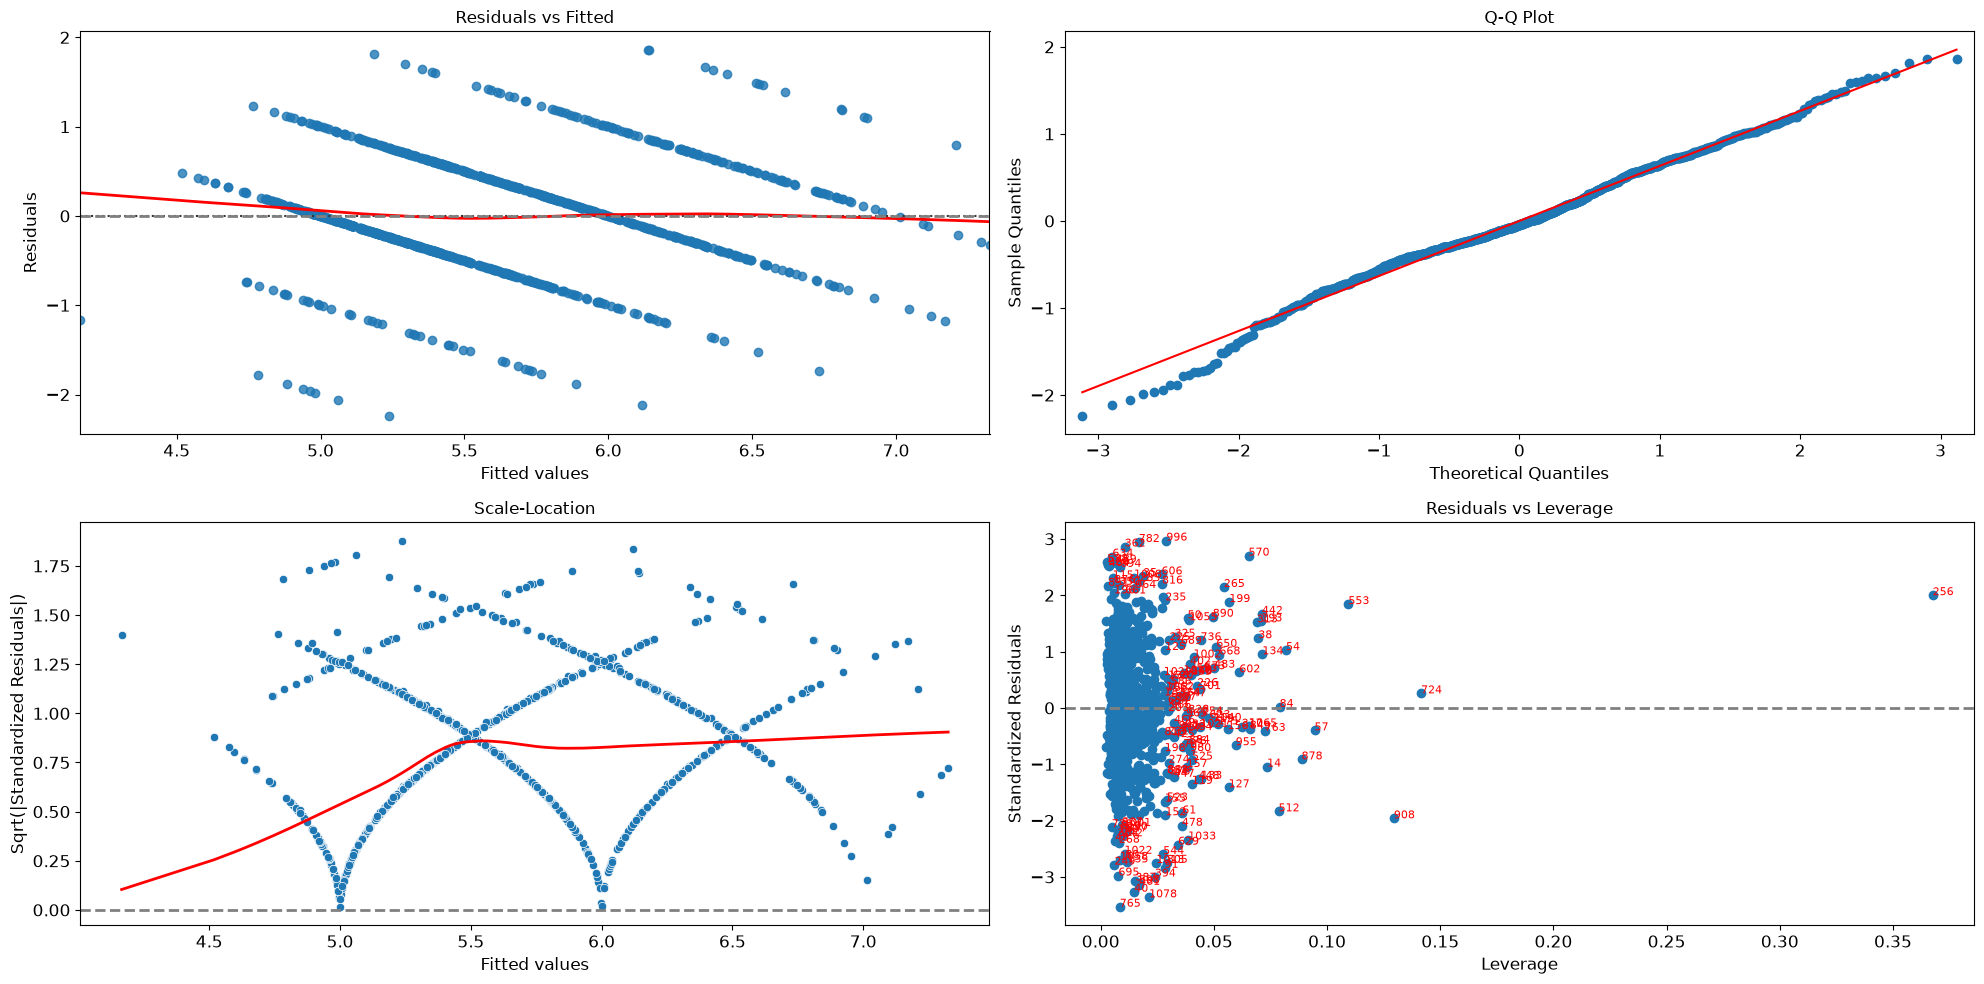

In [77]:
plot_diagnostic_plots(base_model_3)

Compare the polynomial model summary and residual diagnostics. Increased training fit does not establish improved generalisation.

### Training diagnostics

AIC, BIC and adjusted R-squared below describe each fitted model. Models fitted to different observations or likelihoods should not be ranked directly using these values. Use the later common evaluation rows to compare prediction errors, with the exploratory selection caveat.

In [78]:
model_results = extract_and_rank_model_metrics(base_model_3, 'base_model_3', 'Base model with polynomial features and interaction terms', model_results)

In [79]:
display(model_results)

,Model_Name,Model_Description,Adj_R_squared,AIC,BIC
0,base_model,Base model with all features,0.358701,2194.769586,2254.663709
1,base_model_2,Model after removing most influential points,0.381079,2136.848961,2196.676663
2,base_model_3,Base model with polynomial features and intera...,0.399740,2107.702033,2187.472302


The polynomial and interaction terms change the training fit. This alone does not establish better predictions, and residual diagnostics still need review.

----


WLS and heteroskedasticity-robust standard errors are exploratory alternatives. They do not fix omitted variables, dependence, causal identification or feature-selection uncertainty.

### Weighted least squares

In [80]:
model_wls, vif_data_wls = fit_and_evaluate_model(X_train_model_2, y_train_model_2, wls = True)
print(model_wls.summary())

print(vif_data_wls)

                            WLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.341
Model:                            WLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     50.34
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           3.81e-89
Time:                        23:34:12   Log-Likelihood:                -1039.7
No. Observations:                1081   AIC:                             2103.
Df Residuals:                    1069   BIC:                             2163.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6336 

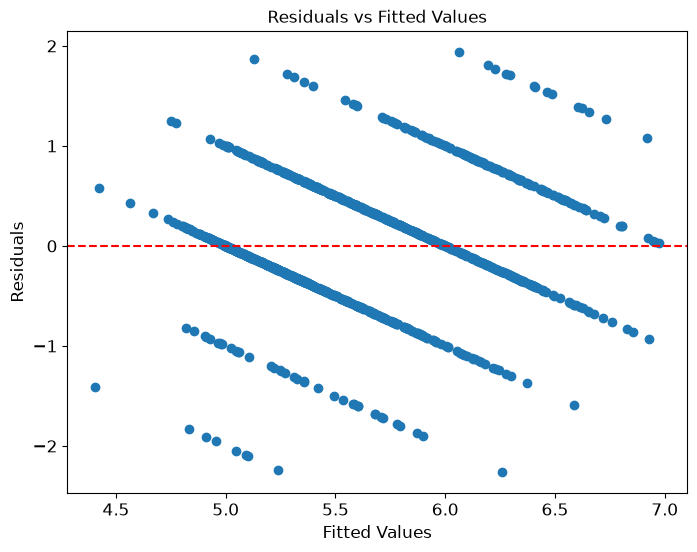

<Figure size 800x600 with 0 Axes>

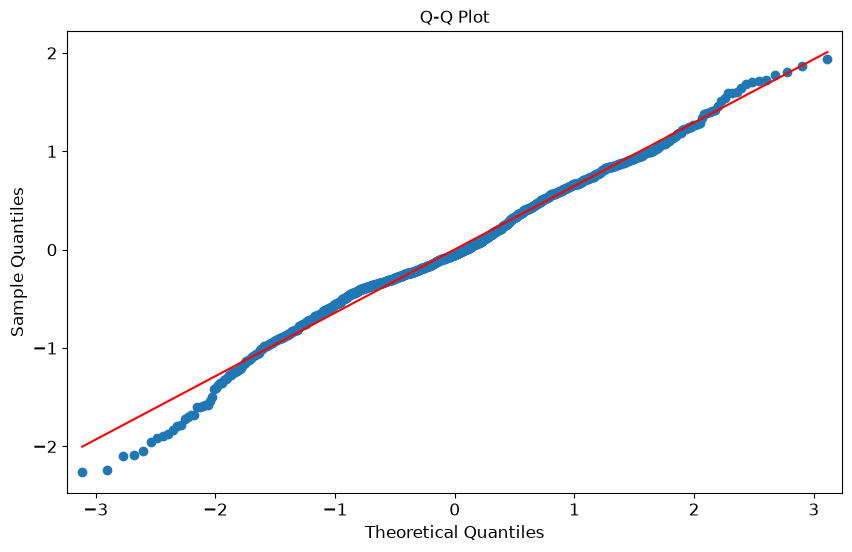

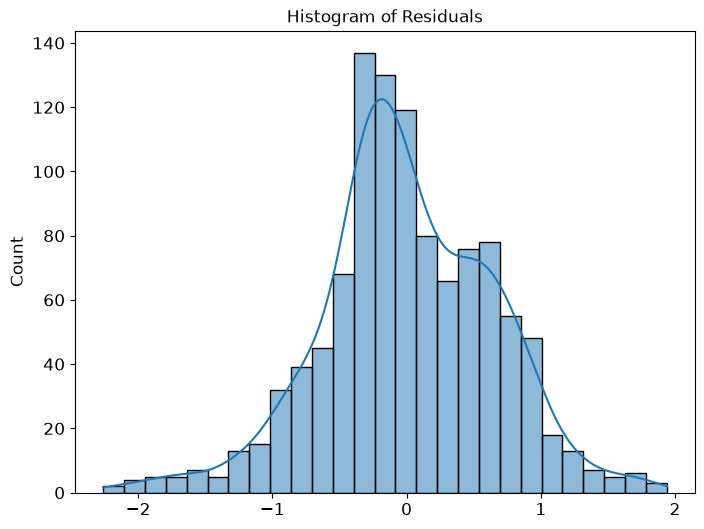

In [81]:
plt.figure(figsize=(8, 6))
plt.scatter(model_wls.fittedvalues, model_wls.resid)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.axhline(0, color='red', linestyle='--')
plt.show()

plt.figure(figsize=(8, 6))
sm.qqplot(model_wls.resid, line ='s')
plt.title('Q-Q Plot')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(model_wls.resid, kde=True)
plt.title('Histogram of Residuals')
plt.show()

WLS changes the weighting of training observations. Its residual plots still need interpretation, and it does not establish causal or production validity.

In [82]:
model_results = extract_and_rank_model_metrics(model_wls, 'model_wls', 'model with weighted least squares', model_results)

### Robust Standard Errors

In [83]:
model_robust, vif_robust = fit_and_evaluate_model(X_train_model_3, y_train_model_2, robust= True)
model_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     48.84
Date:                Tue, 08 Sep 2026   Prob (F-statistic):          7.60e-110
Time:                        23:34:14   Log-Likelihood:                -1037.9
No. Observations:                1081   AIC:                             2108.
Df Residuals:                    1065   BIC:                             2187.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          5.6740      0.028    206.236      0.000       5.620       5.728
fixed acidity                  0.0393      0.065      0.609      0.543      -0.087       0.166
volatile acidity              -0.1706      0.031     -5.582      0.000      -0.230      -0.111
citric acid                   -0.0124      0.034     -0.362      0.717      -0.079       0.055
residual sugar                 0.0121      0.031      0.393      0.694      -0.048       0.073
chlorides                     -0.0499      0.027     -1.817      0.069      -0.104       0.004
free sulfur dioxide            0.0373      0.030      1.253      0.210      -0.021       0.096
total sulfur dioxide          -0.0658      0.031     -2.104      0.035      -0.127      -0.005
density                       -0.0770      0.060     -1.273      0.203      -0.196       0.042
pH                            -0.0872      0.041     -2.126      0.033      -0.168      -0.007
sulphates                      0.2750      0.030      9.301      0.000       0.217       0.333
alcohol                        0.2756      0.042      6.584      0.000       0.194       0.358
sulphates^2                   -0.0547      0.020     -2.736      0.006      -0.094      -0.016
volatile_acidity*sulphates    -0.0112      0.027     -0.412      0.680      -0.065       0.042
volatile_acidity*alcohol      -0.0003      0.026     -0.012      0.991      -0.052       0.051
sulphates*alcohol              0.0758      0.025      3.061      0.002       0.027       0.124
==============================================================================
Omnibus:                       10.961   Durbin-Watson:                   1.875
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               13.855
Skew:                          -0.132   Prob(JB):                     0.000980
Kurtosis:                       3.488   Cond. No.                         10.6
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

HC3 standard errors address heteroskedasticity under the model assumptions. Selecting features using their p-values is exploratory and introduces additional uncertainty.

**Modeling with statistically significant features**

In [84]:
summary = model_robust.summary2().tables[1]

significant_features = summary[summary['P>|z|'] < 0.05].index

X_train_significant = X_train_model_3[significant_features]

model_significant, vif_significant = fit_and_evaluate_model(X_train_significant, y_train_model_2, robust=True)

print(model_significant.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     100.6
Date:                Tue, 08 Sep 2026   Prob (F-statistic):          5.78e-113
Time:                        23:34:14   Log-Likelihood:                -1044.5
No. Observations:                1081   AIC:                             2105.
Df Residuals:                    1073   BIC:                             2145.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6722 

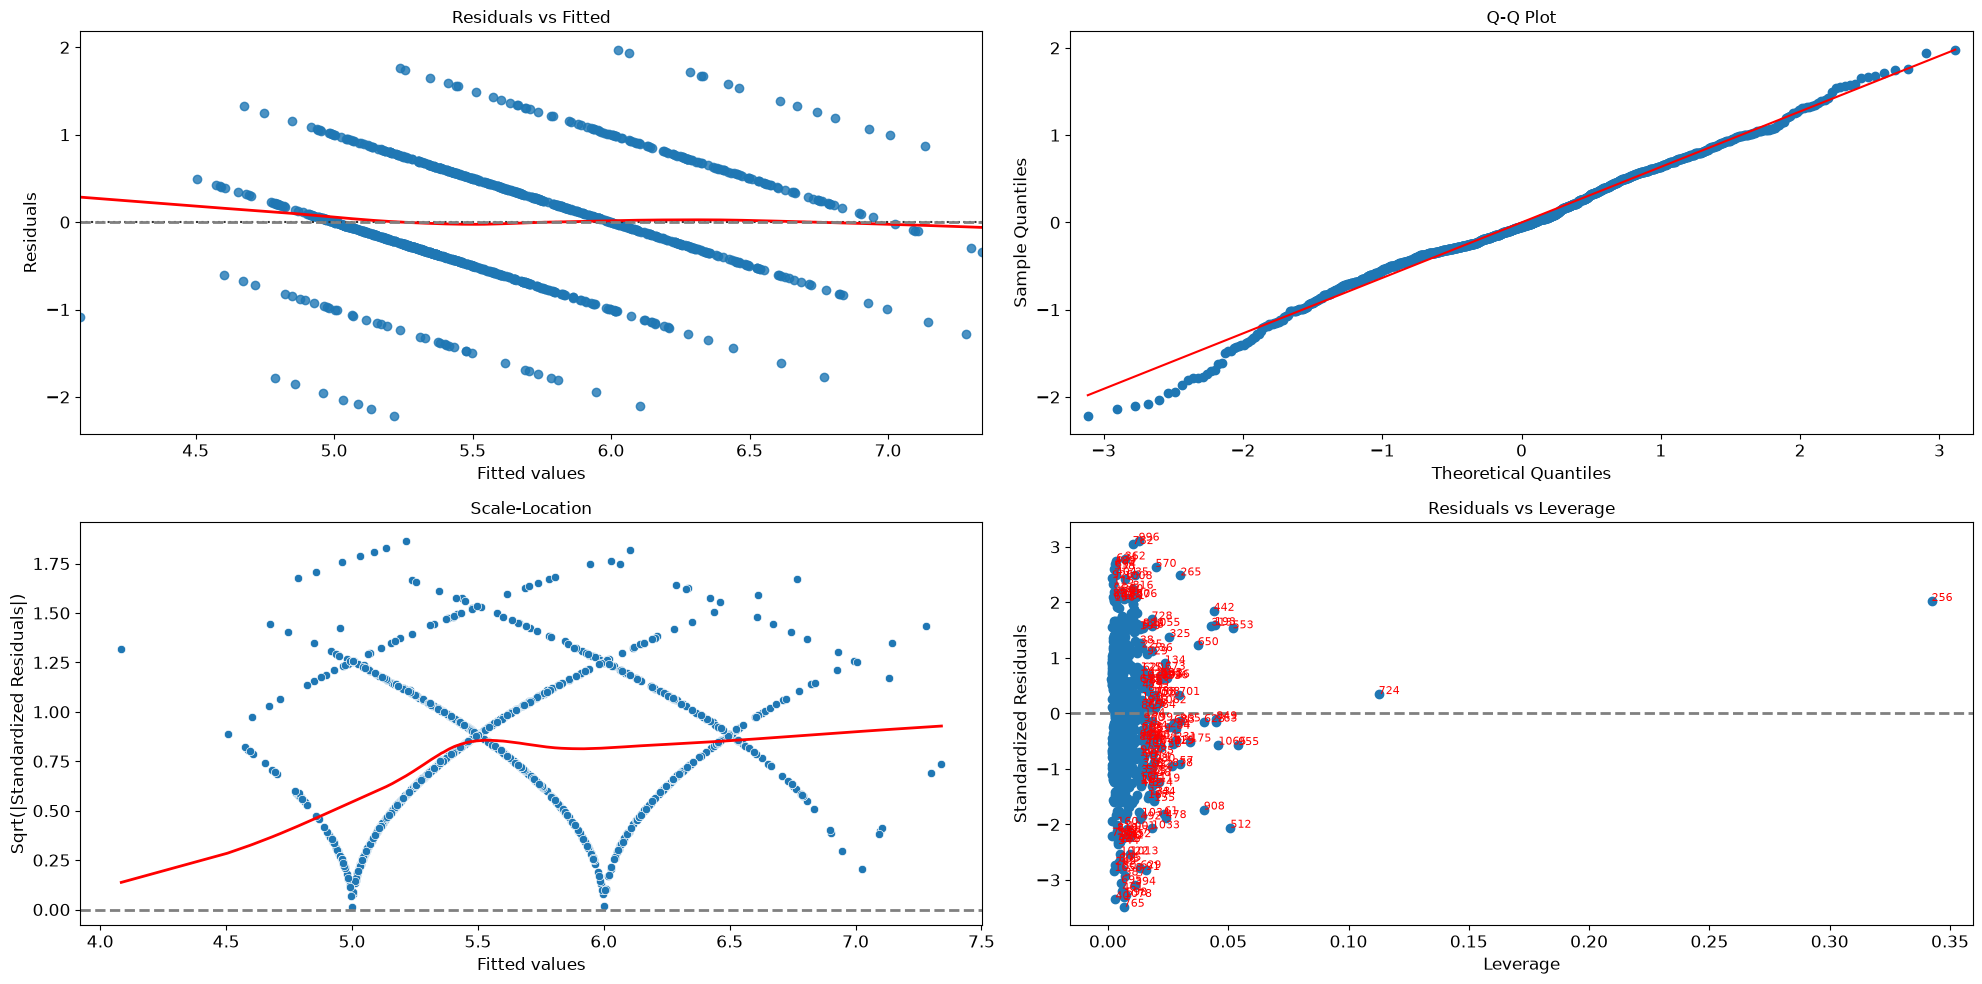

In [85]:
plot_diagnostic_plots(model_significant)

Inspect the residual diagnostics for the reduced model. Feature selection does not guarantee that the model assumptions hold.

### Comparing Models

In [86]:
model_results = extract_and_rank_model_metrics(model_significant, 'model significant', 'Model using robust standard error and non significant features removed', model_results)


In [87]:
display(model_results)

,Model_Name,Model_Description,Adj_R_squared,AIC,BIC
0,base_model,Base model with all features,0.358701,2194.769586,2254.663709
1,base_model_2,Model after removing most influential points,0.381079,2136.848961,2196.676663
2,base_model_3,Base model with polynomial features and intera...,0.399740,2107.702033,2187.472302
3,model_wls,model with weighted least squares,0.334465,2103.437724,2163.265425
4,model significant,Model using robust standard error and non sign...,0.396832,2105.016231,2144.901366


### Predictive Performance

- Looking at the Mean squared error metric 

In [88]:
y_pred_base = base_model.predict(X_test_base_model)
y_pred_base_2 = base_model_2.predict(X_test_model_2)
y_pred_base_3 = base_model_3.predict(X_test_model_3)
y_pred_significant = model_significant.predict(X_test_model_3[significant_features])

mse_base = mean_squared_error(y_test_base_model, y_pred_base)
r2_base = r2_score(y_test_base_model, y_pred_base)

mse_base_2 = mean_squared_error(y_test_model_2, y_pred_base_2)
r2_base_2 = r2_score(y_test_model_2, y_pred_base_2)

mse_base_3 = mean_squared_error(y_test_model_2, y_pred_base_3)
r2_base_3 = r2_score(y_test_model_2, y_pred_base_3)

mse_significant = mean_squared_error(y_test_model_2, y_pred_significant)
r2_significant = r2_score(y_test_model_2, y_pred_significant)

In [89]:
data = {
    'Model_Name': ['base_model', 'base_model_2', 'base_model_3', 'model_significant'],
    'MSE': [mse_base, mse_base_2, mse_base_3, mse_significant],
    'R_squared': [r2_base, r2_base_2, r2_base_3, r2_significant],
    'Model_Description': ['Base model with all features',
                          'Model after removing most influential points',
                          'Base model with polynomial features and interactions',
                          'Model using robust standard error and non-significant features removed']
}

df_metrics = pd.DataFrame(data)

In [90]:
df_metrics

,Model_Name,MSE,R_squared,Model_Description
0,base_model,0.422410,0.370322,Base model with all features
1,base_model_2,0.419609,0.374497,Model after removing most influential points
2,base_model_3,0.414558,0.382026,Base model with polynomial features and intera...
3,model_significant,0.419212,0.375089,Model using robust standard error and non-sign...


In [91]:
lowest_mse = df_metrics.nsmallest(1, "MSE")
display(lowest_mse)

,Model_Name,MSE,R_squared,Model_Description
2,base_model_3,0.414558,0.382026,Base model with polynomial features and intera...


The table above identifies the lowest observed MSE on this split. Because several modelling choices followed exploration of the same dataset, this comparison is not a final unbiased estimate of future performance.

### **Linear Regression - Summary**

The models leave substantial residual variation. Diagnostic plots and the exploratory selection of features limit interpretation. Regularisation and other model families are outside this notebook; low VIF alone would not rule out their usefulness.

-------

Next, model the binary outcome of a rating of at least 7. This is a different prediction task, so its scores are not directly comparable with regression MSE.

----

# Logistic Regression

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

wine_df2['high_quality'] = (wine_df2['quality'] >= 7).astype(int)
classification_features = wine_df2.drop(columns=['quality', 'high_quality'])
classification_target = wine_df2['high_quality']
X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    classification_features, classification_target, test_size=0.2,
    random_state=42, stratify=classification_target)
X_train_raw, X_validation_raw, y_train, y_validation = train_test_split(
    X_dev_raw, y_dev, test_size=0.25, random_state=42, stratify=y_dev)
classification_scaler = StandardScaler().fit(X_train_raw)
def scale_classification(frame):
    return pd.DataFrame(classification_scaler.transform(frame), columns=frame.columns, index=frame.index)
X_train = scale_classification(X_train_raw)
X_validation = scale_classification(X_validation_raw)
X_test = scale_classification(X_test_raw)
assert set(X_train.index).isdisjoint(X_validation.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_validation.index).isdisjoint(X_test.index)
print({'training': len(X_train), 'validation': len(X_validation), 'test': len(X_test)})

{'training': 815, 'validation': 272, 'test': 272}


In [93]:
print(y_train.value_counts(normalize=True))

high_quality
0    0.865031
1    0.134969
Name: proportion, dtype: float64


In [94]:
logit_model = LogisticRegression(class_weight='balanced', random_state=42)
logit_model.fit(X_train, y_train)

y_pred = logit_model.predict(X_test)
y_pred_proba = logit_model.predict_proba(X_test)[:, 1]  

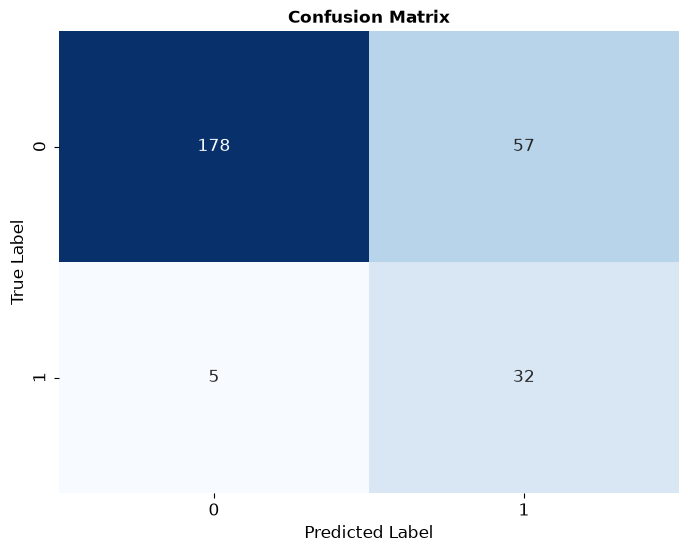

In [95]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontweight = "bold")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The matrix above reports the test-set counts at the default threshold. Read these regenerated values rather than a hard-coded historical count.

In [96]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       235
           1       0.36      0.86      0.51        37

    accuracy                           0.77       272
   macro avg       0.67      0.81      0.68       272
weighted avg       0.89      0.77      0.80       272



The classification report shows precision and recall separately for both classes. Class weighting and the decision threshold affect this trade-off.

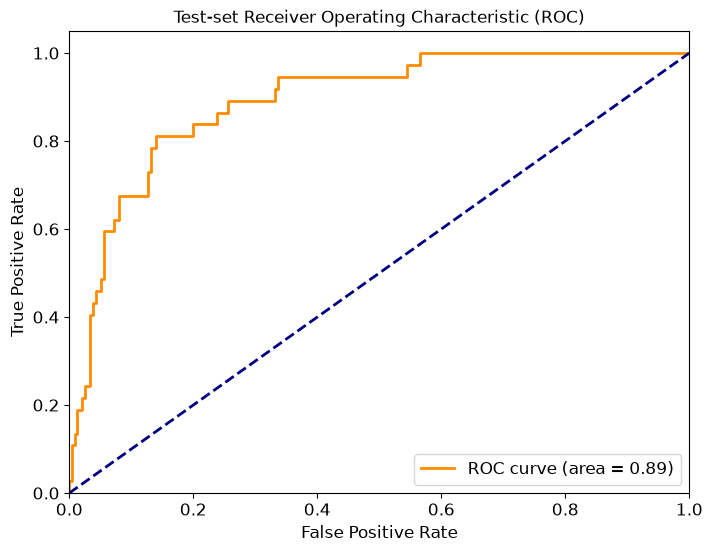

In [97]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test-set Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Compare thresholds on the validation set

The model was fitted on training rows. Threshold selection uses validation labels; test labels are not passed to that calculation.

Results for Threshold: 0.5
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87       235
           1       0.39      0.84      0.53        37

    accuracy                           0.80       272
   macro avg       0.68      0.81      0.70       272
weighted avg       0.89      0.80      0.82       272

Confusion Matrix:


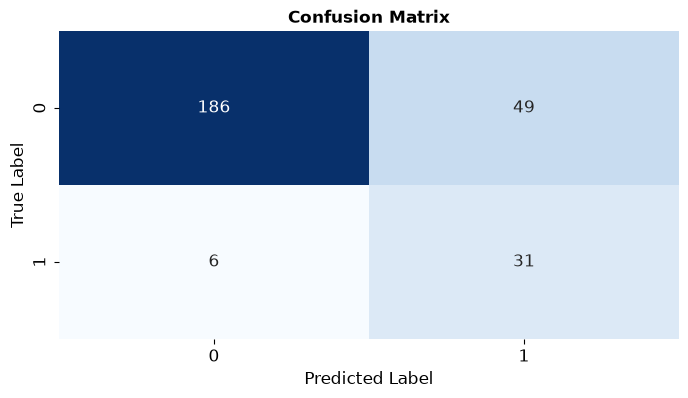

-----------------------------------------------------------------
----------------------------------------------------------------

Results for Threshold: 0.6
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       235
           1       0.39      0.73      0.50        37

    accuracy                           0.81       272
   macro avg       0.67      0.77      0.69       272
weighted avg       0.87      0.81      0.83       272

Confusion Matrix:


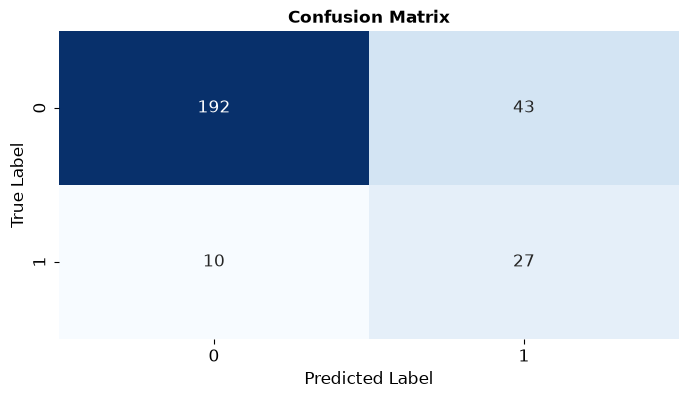

-----------------------------------------------------------------
----------------------------------------------------------------

Results for Threshold: 0.7
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       235
           1       0.43      0.65      0.52        37

    accuracy                           0.83       272
   macro avg       0.68      0.76      0.71       272
weighted avg       0.87      0.83      0.85       272

Confusion Matrix:


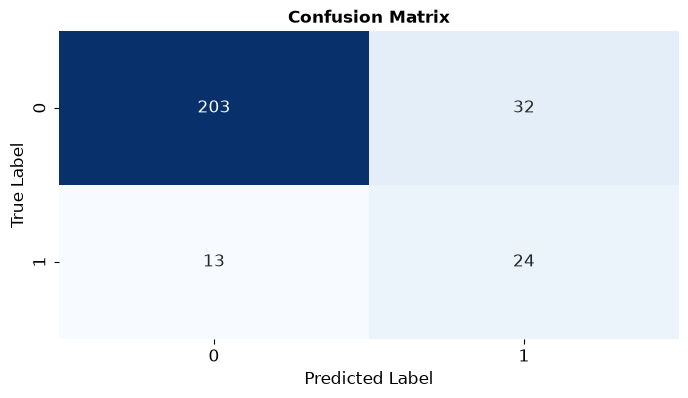

-----------------------------------------------------------------
----------------------------------------------------------------



In [98]:
validation_proba = logit_model.predict_proba(X_validation)[:, 1]
thresholds_to_test = [0.5, 0.6, 0.7]

for threshold in thresholds_to_test:
    y_pred_manual_threshold = (validation_proba >= threshold).astype(int)
    
    print(f"Results for Threshold: {threshold}")
    print("Classification Report:")
    print(classification_report(y_validation, y_pred_manual_threshold))
    print("Confusion Matrix:")
    plt.figure(figsize=(8, 4))
    sns.heatmap(confusion_matrix(y_validation, y_pred_manual_threshold), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix', fontweight = "bold")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print("-----------------------------------------------------------------")
    print("----------------------------------------------------------------\n")

---

### Choose the threshold using validation F1

Best Threshold: 0.739116181495042
Precision at Best Threshold: 0.5
Recall at Best Threshold: 0.6486486486486487
F1 Score at Best Threshold: 0.5647058823529412


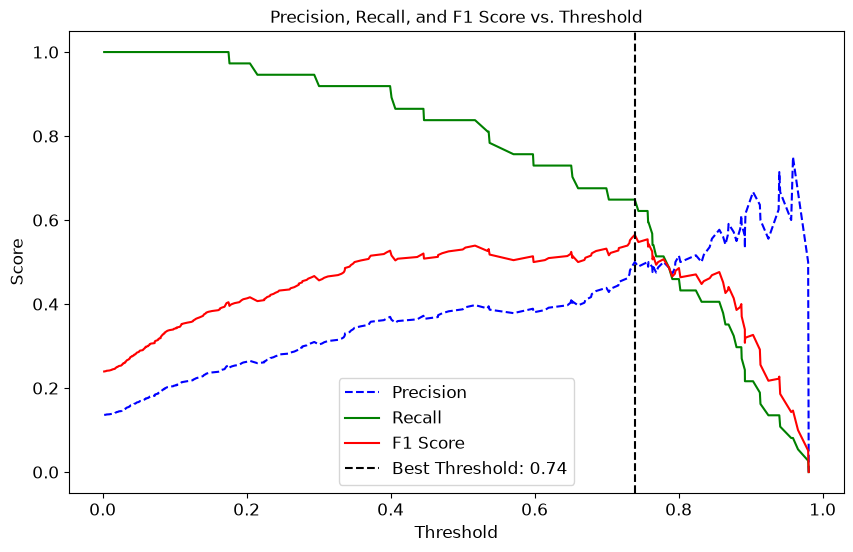

In [99]:
validation_proba = logit_model.predict_proba(X_validation)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_validation, validation_proba)


f1_scores = np.divide(2 * precision[:-1] * recall[:-1], precision[:-1] + recall[:-1], out=np.zeros_like(thresholds), where=(precision[:-1] + recall[:-1]) > 0)

best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]

print(f'Best Threshold: {best_threshold}')
print(f'Precision at Best Threshold: {precision[best_threshold_index]}')
print(f'Recall at Best Threshold: {recall[best_threshold_index]}')
print(f'F1 Score at Best Threshold: {f1_scores[best_threshold_index]}')

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'r-', label='F1 Score')
plt.axvline(x=best_threshold, color='k', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend(loc='best')
plt.show()

In [100]:
y_pred_best_threshold = (y_pred_proba >= best_threshold).astype(int)


Confusion Matrix with Best Threshold:


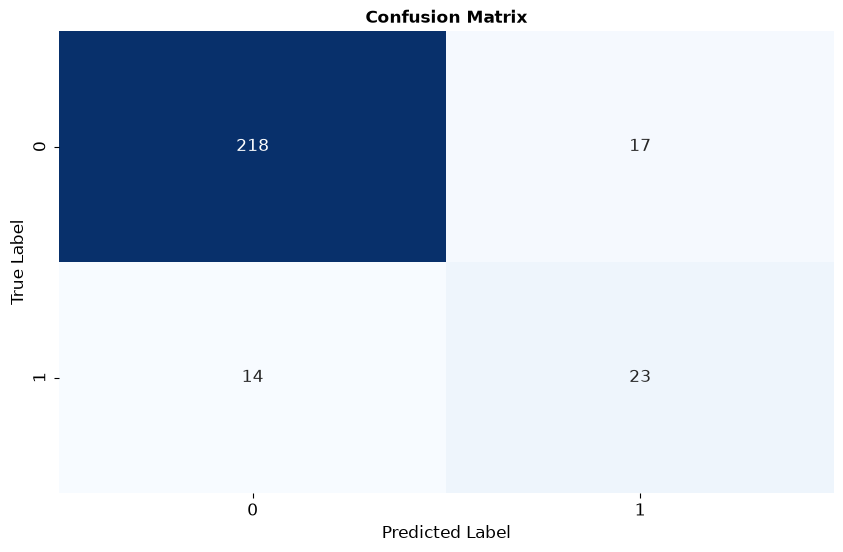

In [101]:
print("Confusion Matrix with Best Threshold:")
sns.heatmap(confusion_matrix(y_test, y_pred_best_threshold), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontweight = "bold")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [102]:
print("Classification Report with Best Threshold:")
print(classification_report(y_test, y_pred_best_threshold))

Classification Report with Best Threshold:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       235
           1       0.57      0.62      0.60        37

    accuracy                           0.89       272
   macro avg       0.76      0.77      0.77       272
weighted avg       0.89      0.89      0.89       272



--------

Coefficients from an unweighted statistical logistic model

In [103]:
X_train_const = sm.add_constant(X_train) 

logit_model_sm = sm.Logit(y_train, X_train_const).fit()

print(logit_model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.271309
         Iterations 8


                           Logit Regression Results                           
Dep. Variable:           high_quality   No. Observations:                  815
Model:                          Logit   Df Residuals:                      803
Method:                           MLE   Df Model:                           11
Date:                Tue, 08 Sep 2026   Pseudo R-squ.:                  0.3144
Time:                        23:34:28   Log-Likelihood:                -221.12
converged:                       True   LL-Null:                       -322.52
Covariance Type:            nonrobust   LLR p-value:                 1.953e-37
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.8314      0.195    -14.527      0.000      -3.213      -2.449
fixed acidity            0.5338      0.316      1.689      0.091      -0.086       1.153
volatile aci

### Logistic regression: interpretation limits

Training, validation and test rows are disjoint. Scaling is fitted on training rows, and the F1 threshold is chosen on validation rows. The final confusion matrix uses test rows. Earlier exploration of the full dataset still limits claims of independent validation. Significance from the separate statistical model is conditional on its assumptions and is not causal evidence.

## Conclusion

This notebook explores associations between wine measurements and quality ratings through plots, hypothesis tests and linear and logistic models. Diagnostics show why model assumptions and evaluation choices need attention.

The classification workflow separates training, threshold selection and test reporting. The overall project remains exploratory because earlier feature choices used this dataset. External validation, repeated evaluation and production deployment are outside its scope.